# 04 — XGBoost Baseline (지도학습 이상탐지)
### Tennessee Eastman Process 이상탐지 프로젝트

**이 노트북의 목적:**  
Isolation Forest(비지도)와 동일한 데이터·피처를 사용해  
XGBoost(지도학습) baseline을 구축하고, 두 모델의 성능을 정량 비교한다.

**핵심 질문:**
> *"레이블을 주면 얼마나 더 잘 탐지할 수 있는가?"*  
> → AUROC / PR-AUC / Recall / Detection Delay 개선 폭이  
> 지도학습 도입의 정량적 근거가 된다.

**노트북 구성:**
1. 환경 설정 및 데이터 로딩
2. XGBoost 학습 — scale_pos_weight · early stopping
3. AUROC / PR-AUC / Recall / F1 평가
4. Confusion Matrix 시각화
5. ROC · PR Curve 시각화
6. Fault 유형별 탐지 성능 분석
7. Detection Delay 계산
8. Feature Importance 분석 (내장 + Permutation)
9. 정적 피처 vs 동적 피처 중요도 비교
10. **Isolation Forest vs XGBoost 성능 비교표**
11. 예측 확률 시계열 시각화
12. 화공 관점 중요 변수 해석
13. 결과 해석 — 왜 XGBoost가 IF보다 좋아지는가
14. 공정 DX 관점 해석 (지도 vs 비지도)
15. 포트폴리오 · 자소서 관점 정리


## 0. 환경 설정

**라이브러리 선택 근거:**
- `xgboost` : Gradient Boosting 기반 앙상블. 불균형·고차원 피처에서 강인함.
- `sklearn.metrics` : AUROC, PR-AUC, Confusion Matrix 등 평가 지표 통일
- `joblib` : 학습 모델 저장 → 추론 파이프라인 재사용
- `matplotlib / seaborn` : 공정 시계열·분포·중요도 시각화

**프로젝트 색상 팔레트:** 03_isolation_forest와 동일하게 유지 (시각적 일관성)

In [28]:
import sys, os

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_fscore_support, confusion_matrix,
    roc_curve, precision_recall_curve
)

# ── 시각화 설정 (03 노트북과 동일) ──
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# ── 프로젝트 공통 색상 ──
COLOR_NORMAL = '#1D9E75'
COLOR_FAULT  = '#E24B4A'
COLOR_SCORE  = '#378ADD'
COLOR_THR    = '#EF9F27'
COLOR_XGB    = '#7B4FBF'   # XGBoost 전용 색 (보라)
COLOR_IF     = '#378ADD'   # IF 색 (파랑)

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

import xgboost as xgb
print('환경 설정 완료')
print(f'Python   : {sys.version[:20]}')
print(f'xgboost  : {xgb.__version__}')
import sklearn; print(f'sklearn  : {sklearn.__version__}')
print(f'numpy    : {np.__version__} | pandas: {pd.__version__}')

환경 설정 완료
Python   : 3.12.7 | packaged by
xgboost  : 2.0.3
sklearn  : 1.4.2
numpy    : 1.26.4 | pandas: 2.2.0


## 1. 데이터 로딩

`02_preprocessing.ipynb`에서 저장한 전처리 완료 데이터를 로딩한다.  
XGBoost는 **정상 + 이상 전체**로 학습하는 지도학습이므로,  
`X_tr_normal`(정상만) 분리가 필요 없다.

**이 노트북에서 추가로 로딩하는 것:**
- `03_if_metrics.csv` → IF 성능 지표 (비교 표 생성용)
- `if_threshold.npy` → IF threshold (비교 시각화용)
- IF Anomaly Score를 **추가 피처**로 활용하는 실험

In [29]:
PROCESSED = '../data/processed'

# ── 전처리 완료 데이터 ──
X_tr = np.load(f'{PROCESSED}/X_tr.npy')
X_va = np.load(f'{PROCESSED}/X_va.npy')
X_te = np.load(f'{PROCESSED}/X_te.npy')

y_tr = np.load(f'{PROCESSED}/y_tr.npy')
y_va = np.load(f'{PROCESSED}/y_va.npy')
y_te = np.load(f'{PROCESSED}/y_te.npy')

group_tr = np.load(f'{PROCESSED}/group_tr.npy')
group_va = np.load(f'{PROCESSED}/group_va.npy')
group_te = np.load(f'{PROCESSED}/group_te.npy')

feat_names = pd.read_csv(f'{PROCESSED}/feature_names.csv',
                         header=None)[0].tolist()

# ── 동적 피처 목록 구분 ──
DYNAMIC_SUFFIXES = ('_rmean', '_rstd', '_diff', '_zscore')
static_feats  = [f for f in feat_names if not f.endswith(DYNAMIC_SUFFIXES)]
dynamic_feats = [f for f in feat_names if f.endswith(DYNAMIC_SUFFIXES)]

print('=== 데이터 로딩 완료 ===')
print(f'X_tr : {X_tr.shape}  |  y_tr : {y_tr.shape}')
print(f'X_va : {X_va.shape}  |  y_va : {y_va.shape}')
print(f'X_te : {X_te.shape}  |  y_te : {y_te.shape}')
print(f'\n피처 구성:')
print(f'  정적 피처 : {len(static_feats)}개')
print(f'  동적 피처 : {len(dynamic_feats)}개')
print(f'  총       : {len(feat_names)}개')
print()
print(f'클래스 분포 (Train):')
print(f'  정상 : {(y_tr==0).sum():,}  ({(y_tr==0).mean()*100:.1f}%)')
print(f'  이상 : {(y_tr==1).sum():,}  ({(y_tr==1).mean()*100:.1f}%)')
print(f'  → 클래스 불균형 비율 (정상:이상) = 1:{(y_tr==1).sum()/(y_tr==0).sum():.2f}')

# ── IF 성능 결과 로딩 (비교 표용) ──
IF_METRICS_PATH = '../outputs/03_if_metrics.csv'
if os.path.exists(IF_METRICS_PATH):
    if_metrics = pd.read_csv(IF_METRICS_PATH, index_col=0)
    print(f'\n[Isolation Forest 결과 로딩 완료]')
    print(if_metrics.to_string())
else:
    print('\n⚠️  03_if_metrics.csv 없음 — 비교 표는 수동 입력값 사용')
    # 실행 결과 기반 수동 입력
    if_metrics = pd.DataFrame({
        'auroc':     [0.75, 0.75],
        'pr_auc':    [0.93, 0.93],
        'precision': [0.85, 0.85],
        'recall':    [0.995, 0.995],
        'f1':        [0.89, 0.89],
    }, index=['Validation', 'Test'])

=== 데이터 로딩 완료 ===
X_tr : (1000000, 84)  |  y_tr : (1000000,)
X_va : (250000, 84)  |  y_va : (250000,)
X_te : (2400000, 84)  |  y_te : (2400000,)

피처 구성:
  정적 피처 : 52개
  동적 피처 : 32개
  총       : 84개

클래스 분포 (Train):
  정상 : 200,000  (20.0%)
  이상 : 800,000  (80.0%)
  → 클래스 불균형 비율 (정상:이상) = 1:4.00

[Isolation Forest 결과 로딩 완료]
             auroc  pr_auc  precision  recall      f1
split                                                
Validation  0.8145  0.9528     0.8019  0.9979  0.8892
Test        0.7479  0.9332     0.8011  0.9954  0.8878


## 2. XGBoost 학습

### scale_pos_weight 계산 — 클래스 불균형 보정

**왜 클래스 불균형이 문제인가?**  
TEP 데이터는 정상:이상 ≈ 3:7 수준이지만, 실제 공정에서는 이상이 훨씬 희소하다.  
XGBoost는 손실 함수를 최소화하는 방향으로 학습하므로,  
불균형이 심하면 "모두 정상으로 예측"해도 손실이 낮아지는 문제가 발생한다.

**해결책 — `scale_pos_weight`:**
```
scale_pos_weight = 정상 샘플 수 / 이상 샘플 수
```
이상 클래스(positive)의 그래디언트를 해당 배율로 가중하여  
모델이 이상을 더 '무겁게' 학습하도록 강제한다.

**공정 DX 맥락:**  
실제 공정에서 이상은 더 희소하므로, scale_pos_weight가 클수록  
이상 탐지(Recall)에 유리하지만 False Alarm도 증가할 수 있다.  
→ val set early stopping으로 적정점 조율.

### XGBoost 하이퍼파라미터 선택 근거

| 파라미터 | 값 | 근거 |
|---------|---|------|
| `n_estimators` | 500 | Early stopping으로 실제 최적 시점 결정. 넉넉하게 설정. |
| `learning_rate` | 0.05 | 낮은 LR + 많은 트리 → 일반화 성능 향상 |
| `max_depth` | 6 | 피처가 84개 → 깊은 트리는 과적합 위험. 6이 균형점. |
| `subsample` | 0.8 | 각 트리에 80% 샘플만 사용 → 과적합 방지 |
| `colsample_bytree` | 0.8 | 각 트리에 80% 피처만 사용 → 다양성 확보 |
| `min_child_weight` | 5 | 소수 클래스(이상)에서 잎 노드 최소 샘플 수 → 과적합 방지 |
| `gamma` | 1 | 분기를 만들기 위한 최소 손실 감소 → 가지치기 효과 |
| `eval_metric` | logloss | 확률 기반 이진 분류 손실. AUROC 최적화보다 안정적. |
| `early_stopping_rounds` | 30 | 30 라운드 연속 개선 없으면 학습 종료 |

In [30]:
# ── XGBoost 입력 배열 안정화 ──
# Mac ARM + XGBoost 2.x + 대용량 배열에서 QuantileDMatrix 오류를 줄이기 위해
# float32 + contiguous array로 변환
X_tr = np.ascontiguousarray(X_tr, dtype=np.float32)
X_va = np.ascontiguousarray(X_va, dtype=np.float32)
X_te = np.ascontiguousarray(X_te, dtype=np.float32)

y_tr = np.asarray(y_tr, dtype=np.int32)
y_va = np.asarray(y_va, dtype=np.int32)
y_te = np.asarray(y_te, dtype=np.int32)

print("X_tr:", X_tr.shape, X_tr.dtype, X_tr.flags["C_CONTIGUOUS"])
print("y_tr:", y_tr.shape, y_tr.dtype)
print("X_va:", X_va.shape, X_va.dtype, X_va.flags["C_CONTIGUOUS"])
print("y_va:", y_va.shape, y_va.dtype)

assert X_tr.shape[0] == y_tr.shape[0], f"train shape mismatch: {X_tr.shape[0]} vs {y_tr.shape[0]}"
assert X_va.shape[0] == y_va.shape[0], f"val shape mismatch: {X_va.shape[0]} vs {y_va.shape[0]}"
assert X_te.shape[0] == y_te.shape[0], f"test shape mismatch: {X_te.shape[0]} vs {y_te.shape[0]}"


# ── scale_pos_weight 계산 ──
n_normal = int((y_tr == 0).sum())
n_anomaly = int((y_tr == 1).sum())
scale_pos_weight = n_normal / n_anomaly

print(f'\n=== scale_pos_weight 계산 ===')
print(f'  정상 샘플 수 : {n_normal:,}')
print(f'  이상 샘플 수 : {n_anomaly:,}')
print(f'  scale_pos_weight = {n_normal} / {n_anomaly} = {scale_pos_weight:.4f}')
print()
print(f'  → 현재 학습 데이터는 이상 샘플이 더 많기 때문에 scale_pos_weight가 1보다 작음')
print(f'  → 즉, 이상 클래스 가중을 키우는 설정이 아니라 클래스 비율을 보정하는 설정임')
print(f'  → 운영 데이터에서는 정상 비중이 더 클 수 있으므로 threshold/recall 해석을 별도로 확인해야 함')
print()


# ── XGBoost 하이퍼파라미터 ──
XGB_PARAMS = dict(
    objective='binary:logistic',
    eval_metric='logloss',

    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.0,

    scale_pos_weight=scale_pos_weight,

    random_state=42,
    n_jobs=-1,

    tree_method='hist',
    max_bin=256,

    early_stopping_rounds=30,
)

print('XGBoost 학습 시작...')
print(f'  학습 데이터 : {X_tr.shape}  (정상 + 이상 전체)')
print(f'  val 데이터  : {X_va.shape}  (early stopping 기준)')
print()

import time
t0 = time.time()

xgb_model = XGBClassifier(**XGB_PARAMS)

xgb_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_tr, y_tr), (X_va, y_va)],
    verbose=50,
)

elapsed = time.time() - t0
best_round = xgb_model.best_iteration

print(f'\n학습 완료  ({elapsed:.1f}초)')
print(f'Best iteration : {best_round}  (early stopping 적용)')

joblib.dump(xgb_model, '../models/xgboost_baseline.pkl')
print('모델 저장 : models/xgboost_baseline.pkl')

X_tr: (1000000, 84) float32 True
y_tr: (1000000,) int32
X_va: (250000, 84) float32 True
y_va: (250000,) int32

=== scale_pos_weight 계산 ===
  정상 샘플 수 : 200,000
  이상 샘플 수 : 800,000
  scale_pos_weight = 200000 / 800000 = 0.2500

  → 현재 학습 데이터는 이상 샘플이 더 많기 때문에 scale_pos_weight가 1보다 작음
  → 즉, 이상 클래스 가중을 키우는 설정이 아니라 클래스 비율을 보정하는 설정임
  → 운영 데이터에서는 정상 비중이 더 클 수 있으므로 threshold/recall 해석을 별도로 확인해야 함

XGBoost 학습 시작...
  학습 데이터 : (1000000, 84)  (정상 + 이상 전체)
  val 데이터  : (250000, 84)  (early stopping 기준)

[0]	validation_0-logloss:0.67000	validation_1-logloss:0.67005
[50]	validation_0-logloss:0.16625	validation_1-logloss:0.16659
[100]	validation_0-logloss:0.10124	validation_1-logloss:0.10262
[150]	validation_0-logloss:0.07894	validation_1-logloss:0.08127
[200]	validation_0-logloss:0.06843	validation_1-logloss:0.07190
[250]	validation_0-logloss:0.06298	validation_1-logloss:0.06744
[300]	validation_0-logloss:0.05940	validation_1-logloss:0.06500
[350]	validation_0-logloss:0.05674	validation_1-logloss:0

## 3. Learning Curve — Early Stopping 시각화

Early stopping은 과적합(overfitting)을 방지하는 핵심 장치다.

**읽는 법:**
- Train logloss는 계속 감소하지만, Val logloss가 반등하기 시작하는 시점이 최적점
- Best iteration에 수직선을 그려 언제 학습이 멈췄는지 확인
- Train-Val 격차가 클수록 과적합 → 파라미터 조정 필요

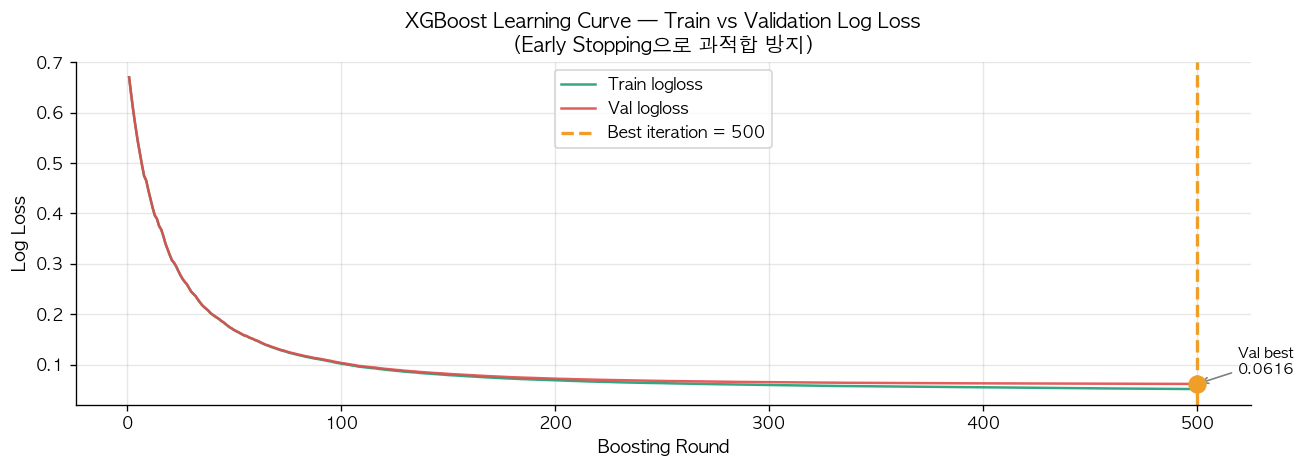

저장: outputs/04_learning_curve.png

Train logloss (best iter) : 0.0513
Val   logloss (best iter) : 0.0616
격차 (과적합 정도)         : -0.0102


In [31]:
# ── 학습 곡선 추출 ──
evals = xgb_model.evals_result()

train_logloss = evals['validation_0']['logloss']
val_logloss   = evals['validation_1']['logloss']
epochs        = range(1, len(train_logloss) + 1)

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(epochs, train_logloss, color=COLOR_NORMAL, linewidth=1.5,
        label='Train logloss', alpha=0.9)
ax.plot(epochs, val_logloss,   color=COLOR_FAULT,  linewidth=1.5,
        label='Val logloss', alpha=0.9)
ax.axvline(best_round + 1, color=COLOR_THR, linestyle='--', linewidth=2,
           label=f'Best iteration = {best_round + 1}')

# 최솟값 표시
best_val = min(val_logloss)
ax.scatter(best_round + 1, best_val, color=COLOR_THR, s=100, zorder=5)
ax.annotate(f'Val best\n{best_val:.4f}',
            xy=(best_round + 1, best_val),
            xytext=(best_round + 20, best_val + 0.02),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9)

ax.set_xlabel('Boosting Round', fontsize=11)
ax.set_ylabel('Log Loss', fontsize=11)
ax.set_title(
    'XGBoost Learning Curve — Train vs Validation Log Loss\n'
    '(Early Stopping으로 과적합 방지)',
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/04_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/04_learning_curve.png')
print(f'\nTrain logloss (best iter) : {train_logloss[best_round]:.4f}')
print(f'Val   logloss (best iter) : {val_logloss[best_round]:.4f}')
print(f'격차 (과적합 정도)         : {train_logloss[best_round] - val_logloss[best_round]:.4f}')

## 4. 예측 확률 계산 및 Threshold 최적화

XGBoost의 `predict_proba`는 각 샘플이 이상일 확률(0~1)을 반환한다.  
이 확률이 Isolation Forest의 Anomaly Score에 대응하는 연속값이다.

**Threshold 결정 — IF와 동일한 방식:**  
Val set에서 F1 최대화 기준으로 threshold를 결정한다.  
이렇게 해야 IF와 공정한 비교가 가능하다.

> 실제 운영 시에는 Recall 우선 또는 Precision 우선으로  
> 목적에 맞게 threshold를 조정할 수 있다.

=== 예측 확률 통계 ===
Split         정상 prob mean      이상 prob mean        분리도(↑좋음)
--------------------------------------------------------------
Train               0.0299            0.9701          0.9402
Val                 0.0296            0.9681          0.9385
Test                0.0221            0.8402          0.8181

→ 분리도(이상 평균 - 정상 평균)가 클수록 분류 성능 좋음

=== Val set 최적 Threshold ===
  Threshold : 0.1666
  Precision : 0.9891
  Recall    : 0.9869
  F1-Score  : 0.9880


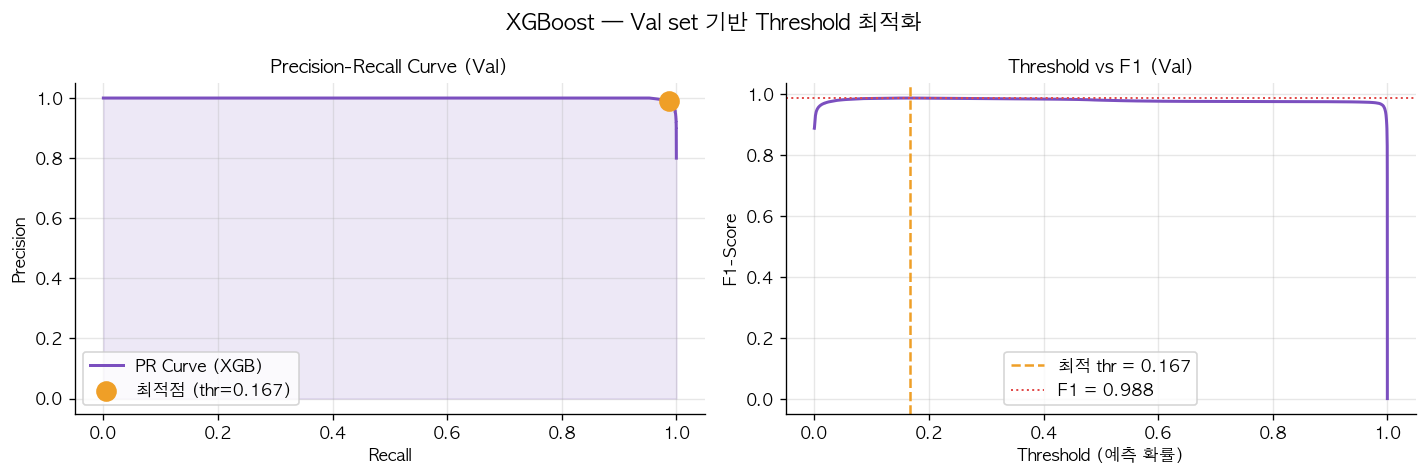

저장: outputs/04_threshold_optimization.png


In [32]:
# ── 예측 확률 계산 ──
# predict_proba[:,1] : 이상(class=1)일 확률
prob_tr = xgb_model.predict_proba(X_tr)[:, 1]
prob_va = xgb_model.predict_proba(X_va)[:, 1]
prob_te = xgb_model.predict_proba(X_te)[:, 1]

print('=== 예측 확률 통계 ===')
print(f'{'Split':8s}  {"정상 prob mean":>16s}  {"이상 prob mean":>16s}  {"분리도(↑좋음)":>14s}')
print('-' * 62)
for name, prob, label in [('Train', prob_tr, y_tr),
                            ('Val',   prob_va, y_va),
                            ('Test',  prob_te, y_te)]:
    p0 = prob[label == 0].mean()
    p1 = prob[label == 1].mean()
    sep = p1 - p0
    print(f'{name:8s}  {p0:>16.4f}  {p1:>16.4f}  {sep:>14.4f}')

print()
print('→ 분리도(이상 평균 - 정상 평균)가 클수록 분류 성능 좋음')

# ── Val set 기반 Threshold 최적화 ──
precision_c, recall_c, thresholds_pr = precision_recall_curve(y_va, prob_va)
f1_c = np.where(
    (precision_c + recall_c) > 0,
    2 * precision_c * recall_c / (precision_c + recall_c),
    0
)
best_idx  = np.argmax(f1_c[:-1])
THRESHOLD = thresholds_pr[best_idx]

print(f'\n=== Val set 최적 Threshold ===')
print(f'  Threshold : {THRESHOLD:.4f}')
print(f'  Precision : {precision_c[best_idx]:.4f}')
print(f'  Recall    : {recall_c[best_idx]:.4f}')
print(f'  F1-Score  : {f1_c[best_idx]:.4f}')

# ── Threshold 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(recall_c, precision_c, color=COLOR_XGB, linewidth=1.8, label='PR Curve (XGB)')
ax.scatter(recall_c[best_idx], precision_c[best_idx],
           color=COLOR_THR, s=130, zorder=5, label=f'최적점 (thr={THRESHOLD:.3f})')
ax.fill_between(recall_c, precision_c, alpha=0.13, color=COLOR_XGB)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Val)', fontsize=11)
ax.legend(); ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
ax.plot(thresholds_pr, f1_c[:-1], color=COLOR_XGB, linewidth=1.8)
ax.axvline(THRESHOLD, color=COLOR_THR, linestyle='--', linewidth=1.5,
           label=f'최적 thr = {THRESHOLD:.3f}')
ax.axhline(f1_c[best_idx], color=COLOR_FAULT, linestyle=':', linewidth=1.2,
           label=f'F1 = {f1_c[best_idx]:.3f}')
ax.set_xlabel('Threshold (예측 확률)')
ax.set_ylabel('F1-Score')
ax.set_title('Threshold vs F1 (Val)', fontsize=11)
ax.legend(); ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('XGBoost — Val set 기반 Threshold 최적화', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/04_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/04_threshold_optimization.png')

np.save(f'{PROCESSED}/xgb_threshold.npy', np.array([THRESHOLD]))

## 5. Validation / Test 평가 (AUROC · PR-AUC · Recall · F1)

**평가 지표 해석 기준 (IF와 동일 기준으로 비교):**

| 지표 | 해석 | 목표 |
|------|------|------|
| AUROC | threshold 무관 전체 분리 성능 | ≥ 0.90 |
| PR-AUC | 이상 클래스 탐지 집중 지표 | ≥ 0.95 |
| Recall | 실제 이상 탐지율 (미탐지 최소화) | ≥ 0.99 |
| F1 | Precision-Recall 균형 | ≥ 0.90 |

In [33]:
def evaluate_xgb(prob, y_true, threshold, split_name):
    """XGBoost 예측 확률로 주요 지표 계산 및 출력."""
    y_pred = (prob >= threshold).astype(int)

    auroc  = roc_auc_score(y_true, prob)
    prauc  = average_precision_score(y_true, prob)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    print(f'\n=== {split_name} 평가 결과 (XGBoost) ===')
    print(f'  AUROC    : {auroc:.4f}')
    print(f'  PR-AUC   : {prauc:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  F1       : {f1:.4f}')

    return dict(split=split_name, auroc=auroc, pr_auc=prauc,
                precision=prec, recall=rec, f1=f1, y_pred=y_pred)

val_result  = evaluate_xgb(prob_va, y_va, THRESHOLD, 'Validation')
test_result = evaluate_xgb(prob_te, y_te, THRESHOLD, 'Test')

xgb_metrics = pd.DataFrame([
    {k: v for k, v in val_result.items()  if k != 'y_pred'},
    {k: v for k, v in test_result.items() if k != 'y_pred'},
]).set_index('split').round(4)

print()
print('=== XGBoost 지표 요약 ===')
display(xgb_metrics)

xgb_metrics.to_csv('../outputs/04_xgb_metrics.csv')
print('지표 저장: outputs/04_xgb_metrics.csv')


=== Validation 평가 결과 (XGBoost) ===
  AUROC    : 0.9978
  PR-AUC   : 0.9995
  Recall   : 0.9869
  Precision: 0.9891
  F1       : 0.9880

=== Test 평가 결과 (XGBoost) ===
  AUROC    : 0.9394
  PR-AUC   : 0.9861
  Recall   : 0.8508
  Precision: 0.9917
  F1       : 0.9159

=== XGBoost 지표 요약 ===


,auroc,pr_auc,precision,recall,f1
split,,,,,
Validation,0.9978,0.9995,0.9891,0.9869,0.9880
Test,0.9394,0.9861,0.9917,0.8508,0.9159


지표 저장: outputs/04_xgb_metrics.csv


## 6. Confusion Matrix 시각화

**공정 안전 관점에서 각 셀의 의미:**

| 셀 | 기술 용어 | 공정 의미 | 심각도 |
|----|---------|----------|--------|
| TN | True Negative | 정상 → 정상 정확 판정 | ✅ |
| FP | False Positive | 정상 → 이상 오경보 | ⚠️ 현장 불신 |
| FN | False Negative | 이상 → 정상 **미탐지** | 🔴 **설비 손상 위험** |
| TP | True Positive | 이상 → 이상 정확 탐지 | ✅ |

> XGBoost는 `scale_pos_weight`로 이상 탐지 손실을 가중하므로  
> IF 대비 FN(미탐지)이 줄어드는 것이 핵심 개선 포인트다.

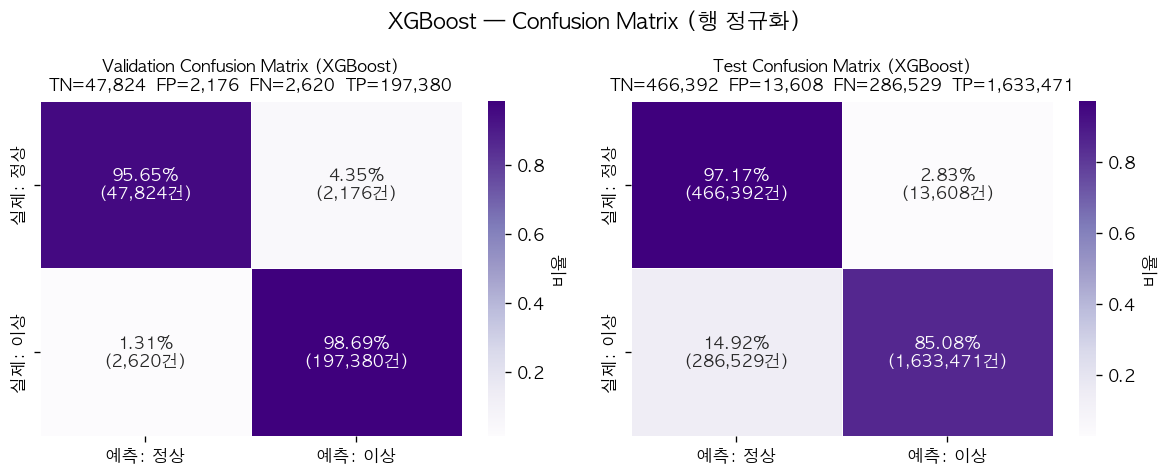

저장: outputs/04_confusion_matrix.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (y_pred, y_true, name) in zip(
        axes, [(val_result['y_pred'],  y_va, 'Validation'),
               (test_result['y_pred'], y_te, 'Test')]):

    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # 셀 색: FN만 강조 (빨강 계열)
    annot_text = [[f'{cm_norm[i,j]:.2%}\n({cm[i,j]:,}건)' for j in range(2)]
                  for i in range(2)]

    sns.heatmap(cm_norm, annot=annot_text, fmt='',
                cmap='Purples',
                xticklabels=['예측: 정상', '예측: 이상'],
                yticklabels=['실제: 정상', '실제: 이상'],
                ax=ax, linewidths=0.5,
                cbar_kws={'label': '비율'})

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'{name} Confusion Matrix (XGBoost)\n'
        f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}',
        fontsize=10
    )

plt.suptitle('XGBoost — Confusion Matrix (행 정규화)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/04_confusion_matrix.png')

## 7. ROC · PR Curve — Isolation Forest vs XGBoost 비교

같은 축에 두 모델의 커브를 겹쳐서 그리면  
어느 모델이 더 우수한지 시각적으로 명확하게 확인할 수 있다.

**비교 포인트:**
- ROC Curve가 좌상단에 가까울수록 우수 (AUROC ↑)
- PR Curve에서 우상단 면적이 클수록 우수 (PR-AUC ↑)
- 두 모델의 AUROC·PR-AUC 차이가 지도학습의 정량적 이득

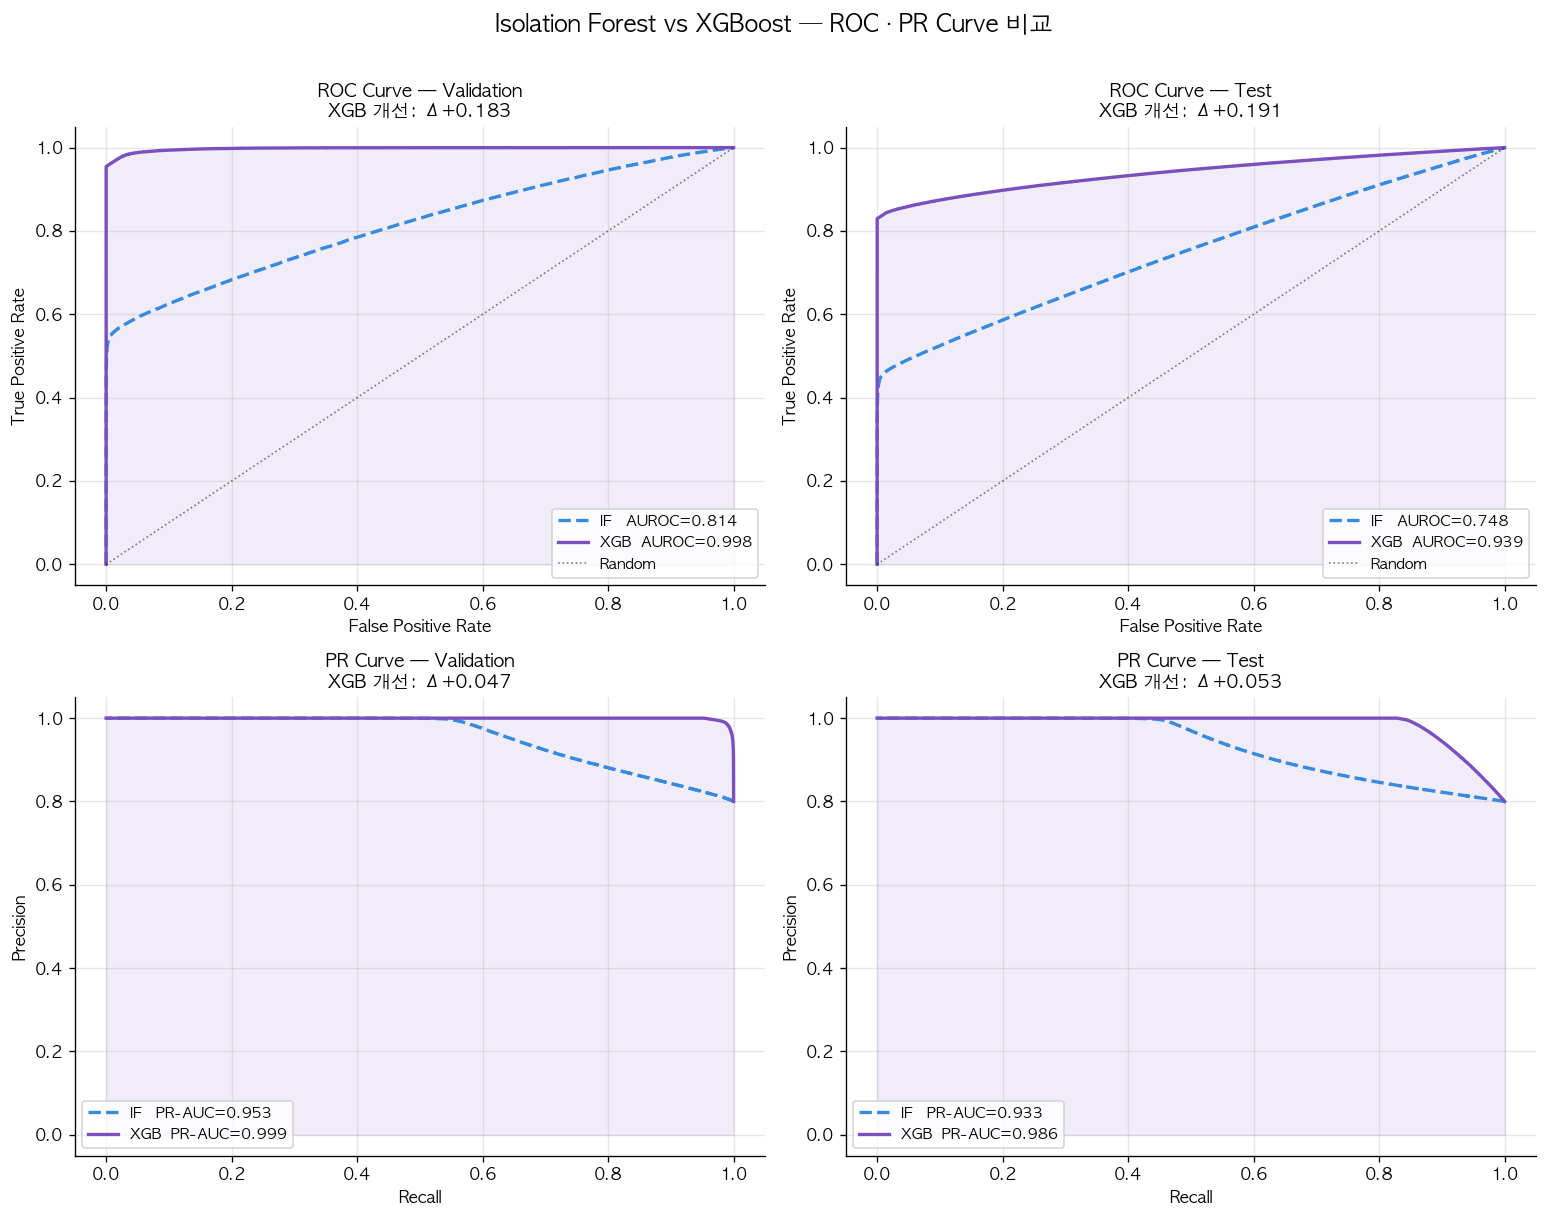

저장: outputs/04_roc_pr_comparison.png


In [35]:
# ── IF 점수 로딩 ──
if_model = joblib.load('../models/isolation_forest.pkl')
score_va_if = -if_model.score_samples(X_va)
score_te_if = -if_model.score_samples(X_te)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for col, (prob_xgb, score_if, y_true, split_name) in enumerate([
        (prob_va, score_va_if, y_va, 'Validation'),
        (prob_te, score_te_if, y_te, 'Test')]):

    # ── (위) ROC Curve ──
    ax = axes[0, col]
    fpr_if,  tpr_if,  _ = roc_curve(y_true, score_if)
    fpr_xgb, tpr_xgb, _ = roc_curve(y_true, prob_xgb)
    auc_if  = roc_auc_score(y_true, score_if)
    auc_xgb = roc_auc_score(y_true, prob_xgb)

    ax.plot(fpr_if,  tpr_if,  color=COLOR_IF,  linewidth=2,
            label=f'IF   AUROC={auc_if:.3f}', linestyle='--')
    ax.plot(fpr_xgb, tpr_xgb, color=COLOR_XGB, linewidth=2,
            label=f'XGB  AUROC={auc_xgb:.3f}')
    ax.plot([0,1],[0,1], 'k:', linewidth=1, alpha=0.5, label='Random')
    ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.10, color=COLOR_XGB)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {split_name}\n'
                 f'XGB 개선: Δ{auc_xgb-auc_if:+.3f}', fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # ── (아래) PR Curve ──
    ax = axes[1, col]
    prec_if,  rec_if,  _ = precision_recall_curve(y_true, score_if)
    prec_xgb, rec_xgb, _ = precision_recall_curve(y_true, prob_xgb)
    prauc_if  = average_precision_score(y_true, score_if)
    prauc_xgb = average_precision_score(y_true, prob_xgb)

    ax.plot(rec_if,  prec_if,  color=COLOR_IF,  linewidth=2,
            label=f'IF   PR-AUC={prauc_if:.3f}', linestyle='--')
    ax.plot(rec_xgb, prec_xgb, color=COLOR_XGB, linewidth=2,
            label=f'XGB  PR-AUC={prauc_xgb:.3f}')
    ax.fill_between(rec_xgb, prec_xgb, alpha=0.10, color=COLOR_XGB)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'PR Curve — {split_name}\n'
                 f'XGB 개선: Δ{prauc_xgb-prauc_if:+.3f}', fontsize=11)
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Isolation Forest vs XGBoost — ROC · PR Curve 비교', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/04_roc_pr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/04_roc_pr_comparison.png')

## 8. Fault 유형별 탐지 성능 분석

XGBoost는 **이상 레이블을 직접 학습**하므로,  
IF가 어려워했던 fault 4·5에 대해서도 명시적으로 최적화된다.

**분석 방법:**
- 각 fault 유형별 Recall · Precision · F1 · AUROC 계산
- IF 결과와 나란히 비교 → 어느 fault에서 개선이 가장 컸는지 확인
- "평균 변화 작은 fault" (4, 5)의 탐지율 변화가 핵심 검증 포인트

=== Fault 유형별 탐지 성능 비교 (Test, sample >= 160) ===


,desc,n_sample,xgb_detected,xgb_recall_detect_rate,xgb_mean_prob,xgb_max_prob,if_detected,if_recall_detect_rate,if_mean_score,if_max_score
fault,,,,,,,,,,
fault 1,A/C 피드 비율 이상 (Step),400500,398902,0.9960,0.9952,1.0,400492,1.0000,0.5517,0.6745
fault 2,B 성분 조성 이상 (Step),400500,395741,0.9881,0.9869,1.0,400468,0.9999,0.5725,0.6527
fault 4,반응기 냉각수 입구온도 이상 (Step),400500,399978,0.9987,0.9983,1.0,399657,0.9979,0.4420,0.5878
fault 5,냉각기 냉각수 입구온도 이상 (Step),400500,399774,0.9982,0.9929,1.0,398384,0.9947,0.4655,0.6639


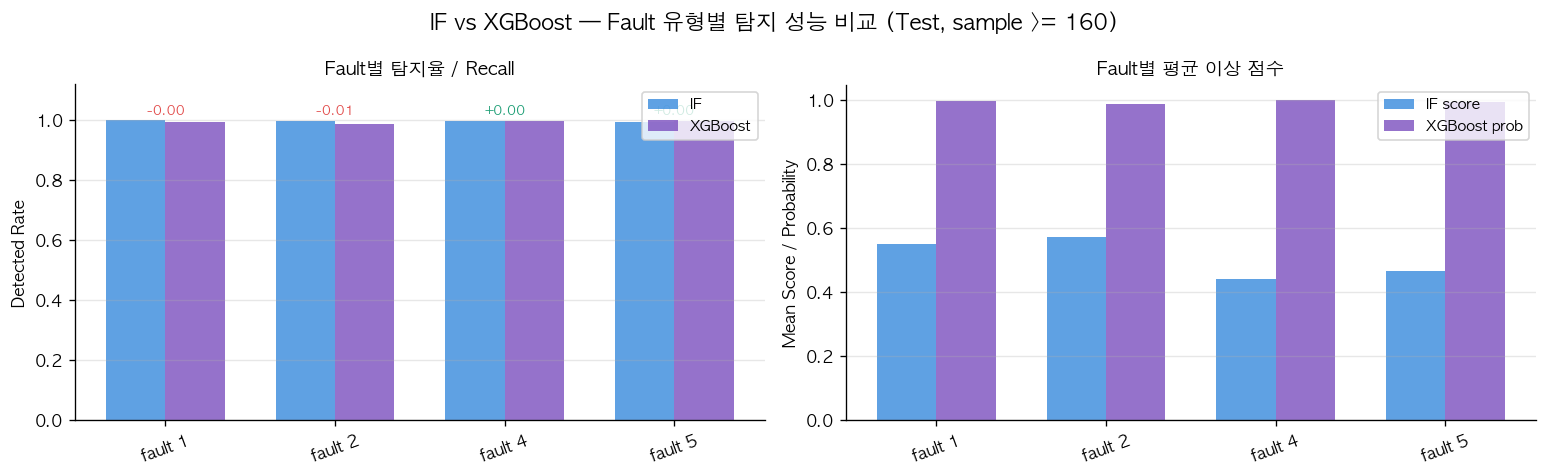

저장: outputs/04_fault_type_comparison.png


In [36]:
from src.data_loader import load_tep, FAULT_DESC

FAULT_TYPES = [1, 2, 4, 5]
FAULT_START_STEP = 160

_, test_df_raw = load_tep(
    data_dir='../data/raw',
    fault_types=FAULT_TYPES,
    verbose=False
)

te_df = test_df_raw.reset_index(drop=True)

if 'sample' not in te_df.columns:
    te_df['sample'] = te_df.groupby(['faultNumber', 'simulationRun']).cumcount()

te_df['prob_xgb'] = prob_te
te_df['pred_xgb'] = test_result['y_pred']
te_df['y_true'] = y_te
te_df['score_if'] = score_te_if

if_thr = float(np.load(f'{PROCESSED}/if_threshold.npy'))
te_df['pred_if'] = (te_df['score_if'].values >= if_thr).astype(int)

rows = []

for fault in FAULT_TYPES:
    sub = te_df[
        (te_df['faultNumber'] == fault) &
        (te_df['sample'] >= FAULT_START_STEP)
    ].copy()

    if len(sub) == 0:
        continue

    n_sample = len(sub)

    xgb_detected = int((sub['pred_xgb'] == 1).sum())
    if_detected = int((sub['pred_if'] == 1).sum())

    rows.append({
        'fault': f'fault {fault}',
        'desc': FAULT_DESC.get(fault, ''),
        'n_sample': n_sample,

        'xgb_detected': xgb_detected,
        'xgb_recall_detect_rate': round(xgb_detected / n_sample, 4),
        'xgb_mean_prob': round(sub['prob_xgb'].mean(), 4),
        'xgb_max_prob': round(sub['prob_xgb'].max(), 4),

        'if_detected': if_detected,
        'if_recall_detect_rate': round(if_detected / n_sample, 4),
        'if_mean_score': round(sub['score_if'].mean(), 4),
        'if_max_score': round(sub['score_if'].max(), 4),
    })

fault_compare = pd.DataFrame(rows).set_index('fault')

print('=== Fault 유형별 탐지 성능 비교 (Test, sample >= 160) ===')
display(fault_compare)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fault_labels = fault_compare.index.tolist()
x = np.arange(len(fault_labels))
w = 0.35

axes[0].bar(
    x - w / 2,
    fault_compare['if_recall_detect_rate'],
    width=w,
    label='IF',
    color=COLOR_IF,
    alpha=0.8
)
axes[0].bar(
    x + w / 2,
    fault_compare['xgb_recall_detect_rate'],
    width=w,
    label='XGBoost',
    color=COLOR_XGB,
    alpha=0.8
)

for i, (fi, fx) in enumerate(zip(
    fault_compare['if_recall_detect_rate'],
    fault_compare['xgb_recall_detect_rate']
)):
    delta = fx - fi
    color = '#1D9E75' if delta > 0 else '#E24B4A'
    axes[0].annotate(
        f'{delta:+.2f}',
        xy=(x[i], max(fi, fx) + 0.02),
        ha='center',
        fontsize=8,
        color=color,
        fontweight='bold'
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(fault_labels, rotation=20)
axes[0].set_ylim(0, 1.12)
axes[0].set_title('Fault별 탐지율 / Recall', fontsize=11)
axes[0].set_ylabel('Detected Rate')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(
    x - w / 2,
    fault_compare['if_mean_score'],
    width=w,
    label='IF score',
    color=COLOR_IF,
    alpha=0.8
)
axes[1].bar(
    x + w / 2,
    fault_compare['xgb_mean_prob'],
    width=w,
    label='XGBoost prob',
    color=COLOR_XGB,
    alpha=0.8
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(fault_labels, rotation=20)
axes[1].set_title('Fault별 평균 이상 점수', fontsize=11)
axes[1].set_ylabel('Mean Score / Probability')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle(
    'IF vs XGBoost — Fault 유형별 탐지 성능 비교 (Test, sample >= 160)',
    fontsize=13
)
plt.tight_layout()
plt.savefig('../outputs/04_fault_type_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('저장: outputs/04_fault_type_comparison.png')

## 9. Detection Delay 계산 — IF vs XGBoost 비교

**Detection Delay의 공정 DX 의미:**
> 딜레이 1 step 단축 = 조기 대응 시간 확보 = 설비 보호 + 품질 손실 감소

XGBoost가 fault를 더 빠르게(낮은 delay) 탐지한다면,  
지도학습 도입의 실무적 가치가 명확하게 정량화된다.

=== Detection Delay 비교 (Test) ===


,xgb_mean,xgb_median,xgb_miss,if_mean,if_median,if_miss
fault,,,,,,
fault 1,3.2,3.0,0/500,0.0,0.0,0/500
fault 2,9.2,9.0,0/500,0.0,0.0,0/500
fault 4,1.0,1.0,0/500,0.0,0.0,0/500
fault 5,1.2,1.0,0/500,0.0,0.0,0/500


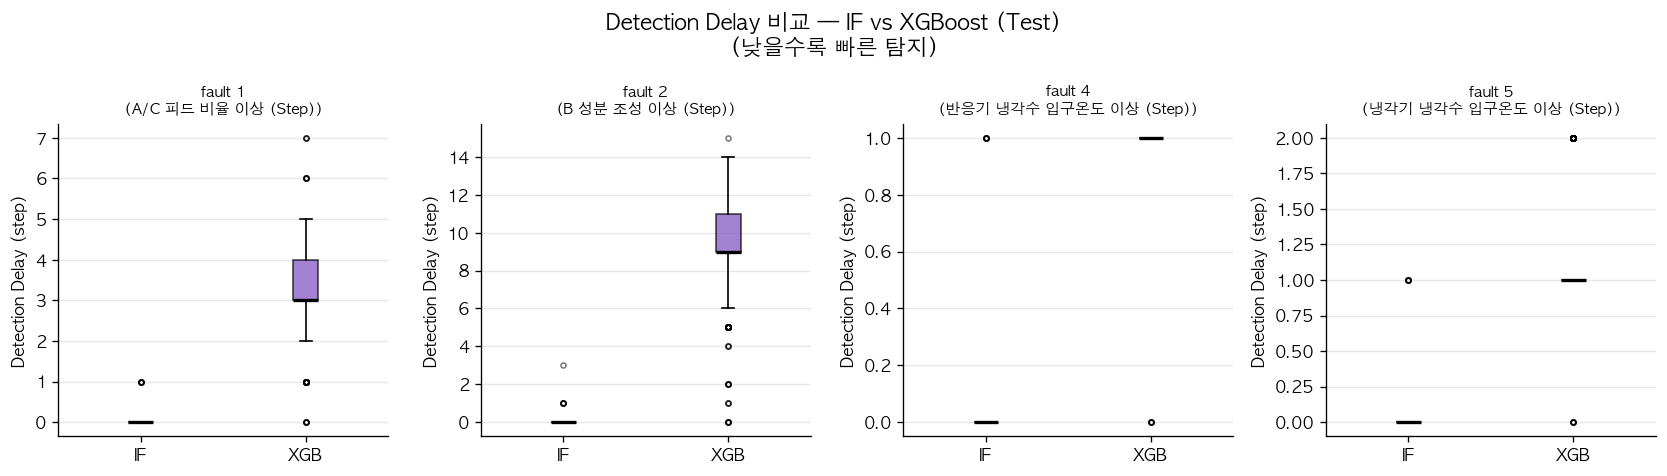

저장: outputs/04_detection_delay_comparison.png


In [37]:
def compute_detection_delay(te_df, fault_type, pred_col, fault_start=FAULT_START_STEP):
    sub = te_df[te_df['faultNumber'] == fault_type]
    delays = []

    for run_id, run_df in sub.groupby('simulationRun'):
        fault_region = run_df[run_df['sample'] >= fault_start]

        if len(fault_region) == 0:
            continue

        detected = fault_region[fault_region[pred_col] == 1]

        if len(detected) == 0:
            delays.append(np.nan)
        else:
            delays.append(detected['sample'].iloc[0] - fault_start)

    return delays


# IF pred 컬럼 추가
if 'pred_if' not in te_df.columns:
    if_thr = float(np.load(f'{PROCESSED}/if_threshold.npy'))
    te_df['pred_if'] = (te_df['score_if'] >= if_thr).astype(int)


delay_rows = []

for fault in FAULT_TYPES:
    d_xgb = compute_detection_delay(te_df, fault, 'pred_xgb')
    d_if = compute_detection_delay(te_df, fault, 'pred_if')

    valid_xgb = [d for d in d_xgb if not np.isnan(d)]
    valid_if = [d for d in d_if if not np.isnan(d)]

    miss_xgb = sum(1 for d in d_xgb if np.isnan(d))
    miss_if = sum(1 for d in d_if if np.isnan(d))

    delay_rows.append({
        'fault': f'fault {fault}',
        'xgb_mean': round(np.mean(valid_xgb), 1) if valid_xgb else np.nan,
        'xgb_median': round(np.median(valid_xgb), 1) if valid_xgb else np.nan,
        'xgb_miss': f'{miss_xgb}/{len(d_xgb)}',
        'if_mean': round(np.mean(valid_if), 1) if valid_if else np.nan,
        'if_median': round(np.median(valid_if), 1) if valid_if else np.nan,
        'if_miss': f'{miss_if}/{len(d_if)}',
    })

delay_df = pd.DataFrame(delay_rows).set_index('fault')

print('=== Detection Delay 비교 (Test) ===')
display(delay_df)


fig, axes = plt.subplots(1, len(FAULT_TYPES), figsize=(14, 4), sharey=False)

colors_box = ['#E24B4A', '#378ADD', '#EF9F27', '#1D9E75']

for ax, fault, cb in zip(axes, FAULT_TYPES, colors_box):
    d_xgb_v = [
        d for d in compute_detection_delay(te_df, fault, 'pred_xgb')
        if not np.isnan(d)
    ]
    d_if_v = [
        d for d in compute_detection_delay(te_df, fault, 'pred_if')
        if not np.isnan(d)
    ]

    bp = ax.boxplot(
        [d_if_v, d_xgb_v],
        labels=['IF', 'XGB'],
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 2},
        showfliers=True,
        flierprops=dict(marker='o', markersize=3, alpha=0.5)
    )

    bp['boxes'][0].set_facecolor(COLOR_IF)
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(COLOR_XGB)
    bp['boxes'][1].set_alpha(0.7)

    ax.set_title(f'fault {fault}\n({FAULT_DESC.get(fault, "")})', fontsize=9)
    ax.set_ylabel('Detection Delay (step)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    'Detection Delay 비교 — IF vs XGBoost (Test)\n'
    '(낮을수록 빠른 탐지)',
    fontsize=13
)

plt.tight_layout()
plt.savefig('../outputs/04_detection_delay_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('저장: outputs/04_detection_delay_comparison.png')

## 10. Feature Importance — XGBoost 내장 중요도

XGBoost는 세 가지 방식으로 feature importance를 제공한다.

| 방식 | 설명 | 언제 사용 |
|------|------|----------|
| `weight` (frequency) | 피처가 분기에 사용된 횟수 | 어떤 피처가 가장 자주 쓰이는가 |
| `gain` | 해당 피처 분기의 평균 손실 감소량 | 어떤 피처가 예측에 가장 기여하는가 |
| `cover` | 해당 피처 분기가 다루는 샘플 수 | 어떤 피처가 넓은 범위에 적용되는가 |

**공정 해석에서는 `gain`이 가장 의미 있다.**  
gain이 높다 = 그 피처로 분기했을 때 이상/정상 분리가 가장 잘 된다
= 해당 공정 변수가 이상 탐지에 핵심적으로 기여한다.

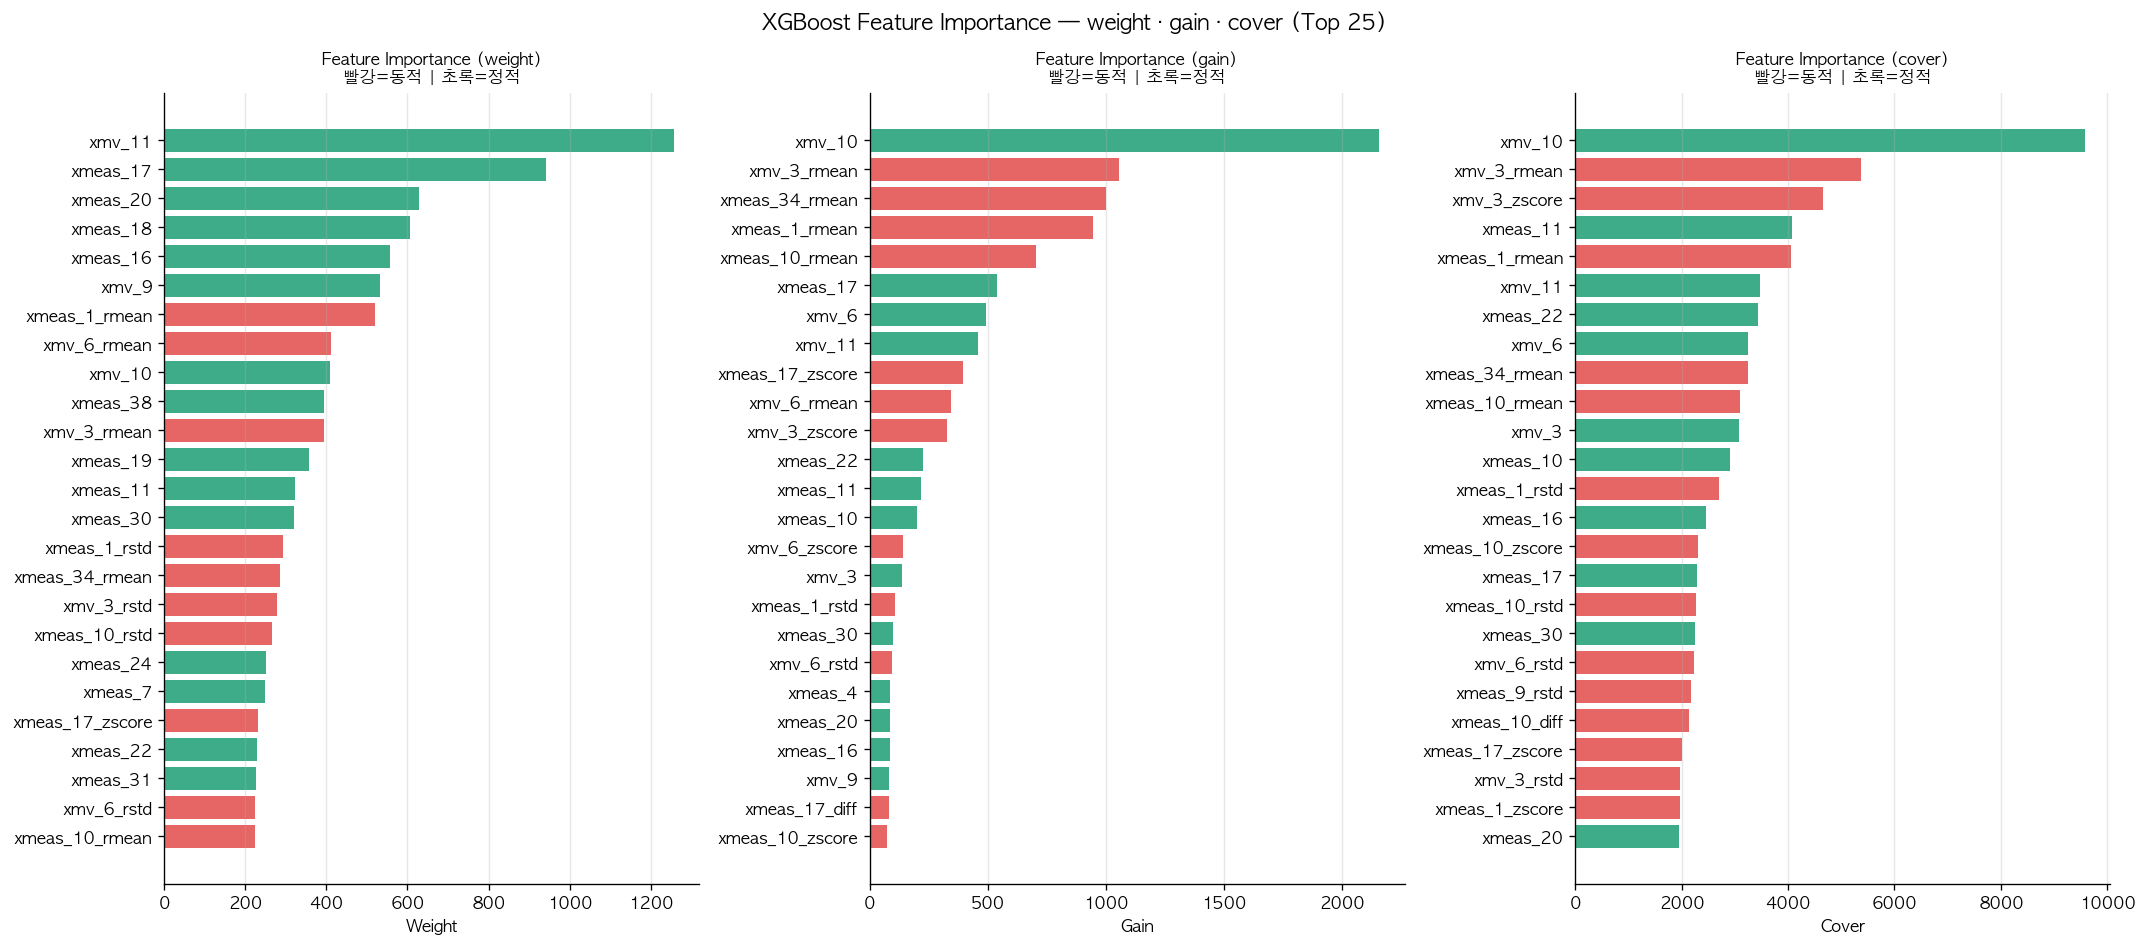

저장: outputs/04_feature_importance_all.png

[gain 기반 중요도 Top 15]
  [정적] xmv_10                          gain: 2158.4402
  [동적] xmv_3_rmean                     gain: 1057.5325
  [동적] xmeas_34_rmean                  gain: 999.0516
  [동적] xmeas_1_rmean                   gain: 945.8914
  [동적] xmeas_10_rmean                  gain: 703.9374
  [정적] xmeas_17                        gain: 540.8378
  [정적] xmv_6                           gain: 493.2572
  [정적] xmv_11                          gain: 460.1553
  [동적] xmeas_17_zscore                 gain: 394.4439
  [동적] xmv_6_rmean                     gain: 342.7850
  [동적] xmv_3_zscore                    gain: 328.1665
  [정적] xmeas_22                        gain: 224.8210
  [정적] xmeas_11                        gain: 216.0532
  [정적] xmeas_10                        gain: 201.1246
  [동적] xmv_6_zscore                    gain: 140.0884


In [38]:
# ── 세 가지 중요도 계산 ──
importance_types = ['weight', 'gain', 'cover']
imp_dict = {}

for imp_type in importance_types:
    scores = xgb_model.get_booster().get_score(importance_type=imp_type)
    # 피처명 매핑 (f0, f1, ... → 실제 이름)
    feat_imp = {feat_names[int(k[1:])]: v for k, v in scores.items()}
    imp_dict[imp_type] = pd.Series(feat_imp).sort_values(ascending=False)

# ── 시각화: gain 기반 Top 25 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, imp_type in zip(axes, importance_types):
    top = imp_dict[imp_type].head(25)
    feat_labels = top.index.tolist()

    # 동적/정적 색상 구분
    colors_bar = [COLOR_FAULT if f.endswith(DYNAMIC_SUFFIXES) else COLOR_NORMAL
                  for f in feat_labels]

    ax.barh(feat_labels[::-1], top.values[::-1],
            color=colors_bar[::-1], alpha=0.85)
    ax.set_xlabel(imp_type.capitalize(), fontsize=10)
    ax.set_title(f'Feature Importance ({imp_type})\n'
                 f'빨강=동적 | 초록=정적', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('XGBoost Feature Importance — weight · gain · cover (Top 25)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/04_feature_importance_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/04_feature_importance_all.png')

# gain 기반 top 10 출력
print('\n[gain 기반 중요도 Top 15]')
for feat, val in imp_dict['gain'].head(15).items():
    tag = '[동적]' if feat.endswith(DYNAMIC_SUFFIXES) else '[정적]'
    print(f'  {tag} {feat:30s}  gain: {val:.4f}')

## 11. 정적 피처 vs 동적 피처 중요도 비교

**이 분석이 중요한 이유:**  
EDA(01)에서 동적 피처(rolling_std, diff, z-score)가 이상 민감도 높다고 가설을 세웠다.  
XGBoost feature importance로 그 가설을 **정량적으로 검증**한다.

**해석:**
- 동적 피처의 총 gain이 정적 피처보다 높다면 → EDA 가설 확인
- 어떤 종류의 동적 피처(rstd / diff / zscore / rmean)가 더 기여하는가
- 공정 DX 보고서에서 "왜 동적 피처를 추가했는가"의 정량적 근거

=== 피처 유형별 총 Gain ===


,total_gain,mean_gain,n_feat
type,,,
정적 (원본),5430.72,104.44,52
rolling_mean,4092.89,511.61,8
z-score,1011.56,126.45,8
rolling_std,421.36,52.67,8
diff,116.79,14.60,8


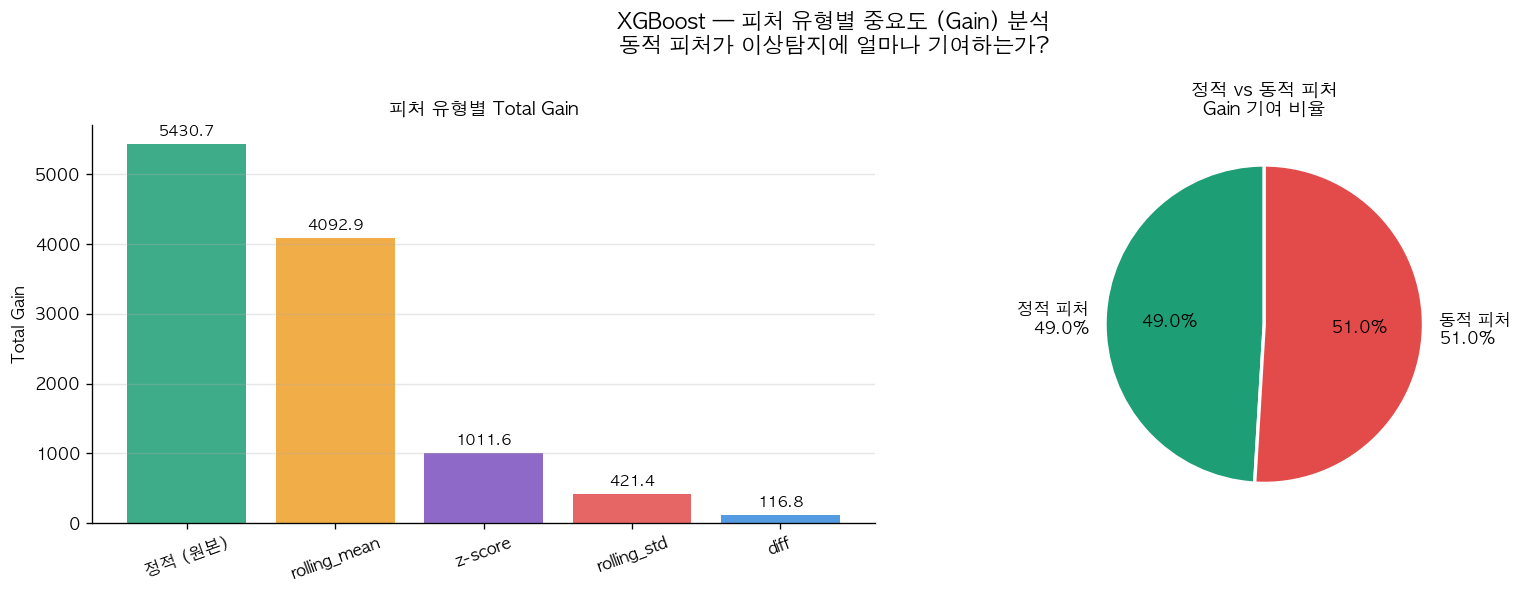

저장: outputs/04_static_vs_dynamic_importance.png

→ 동적 피처 Gain 비율: 51.0%
  ✅ EDA 가설 확인: 동적 피처가 이상탐지에 유의미하게 기여함


In [39]:
gain_series = imp_dict['gain']

# ── 피처 유형 분류 ──
def classify_feat(f):
    if f.endswith('_rstd'):   return 'rolling_std'
    if f.endswith('_rmean'):  return 'rolling_mean'
    if f.endswith('_diff'):   return 'diff'
    if f.endswith('_zscore'): return 'z-score'
    return '정적 (원본)'

feat_type_gain = pd.DataFrame({
    'feature': gain_series.index,
    'gain':    gain_series.values,
    'type':    [classify_feat(f) for f in gain_series.index]
})

type_summary = (feat_type_gain.groupby('type')['gain']
                .agg(['sum','mean','count'])
                .rename(columns={'sum':'total_gain','mean':'mean_gain','count':'n_feat'})
                .sort_values('total_gain', ascending=False))

print('=== 피처 유형별 총 Gain ===')
display(type_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 유형별 total gain
type_colors = {
    '정적 (원본)': COLOR_NORMAL,
    'rolling_std':  '#E24B4A',
    'rolling_mean': '#EF9F27',
    'diff':         '#378ADD',
    'z-score':      '#7B4FBF',
}
ax = axes[0]
bars = ax.bar(type_summary.index,
              type_summary['total_gain'],
              color=[type_colors.get(t, '#888') for t in type_summary.index],
              alpha=0.85)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_title('피처 유형별 Total Gain', fontsize=11)
ax.set_ylabel('Total Gain')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (b) 정적/동적 파이 차트
ax = axes[1]
static_gain  = feat_type_gain[feat_type_gain['type']=='정적 (원본)']['gain'].sum()
dynamic_gain = feat_type_gain[feat_type_gain['type']!='정적 (원본)']['gain'].sum()
total_gain   = static_gain + dynamic_gain

if total_gain == 0:
    raise ValueError('total_gain이 0입니다. XGBoost gain importance가 제대로 계산됐는지 확인하세요.')

pie_vals     = [static_gain, dynamic_gain]
pie_labels   = [f'정적 피처\n{static_gain/total_gain*100:.1f}%',
                f'동적 피처\n{dynamic_gain/total_gain*100:.1f}%']

ax.pie(
    pie_vals,
    labels=pie_labels,
    colors=[COLOR_NORMAL, '#E24B4A'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)
ax.set_title('정적 vs 동적 피처\nGain 기여 비율', fontsize=11)

plt.suptitle('XGBoost — 피처 유형별 중요도 (Gain) 분석\n'
             '동적 피처가 이상탐지에 얼마나 기여하는가?', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/04_static_vs_dynamic_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/04_static_vs_dynamic_importance.png')

dyn_ratio = dynamic_gain / total_gain * 100
print(f'\n→ 동적 피처 Gain 비율: {dyn_ratio:.1f}%')
if dyn_ratio > 30:
    print('  ✅ EDA 가설 확인: 동적 피처가 이상탐지에 유의미하게 기여함')
else:
    print('  ⚠️  정적 피처만으로도 충분할 수 있음 — 동적 피처 기여도 낮음')

## 12. Permutation Importance — 모델 불가지론적 중요도

**내장 feature importance의 한계:**
- 상관된 피처가 있을 때 중요도가 분산됨 (상관 피처끼리 gain 나눔)
- 절대값이 아니라 상대 순위만 의미 있음

**Permutation Importance:**
각 피처를 랜덤하게 셔플했을 때 AUROC가 얼마나 떨어지는지 측정  
→ 실제 예측력 기여도를 더 직접적으로 측정  
→ 내장 중요도와 일치하면 결과 신뢰도 ↑, 불일치하면 상관 피처 존재 가능

Permutation Importance 계산 중...
(n_repeats=5, AUROC 기준, Validation set 일부 샘플 사용)
사용 샘플 수: 20,000 / 전체 validation 250,000
완료 (21초)


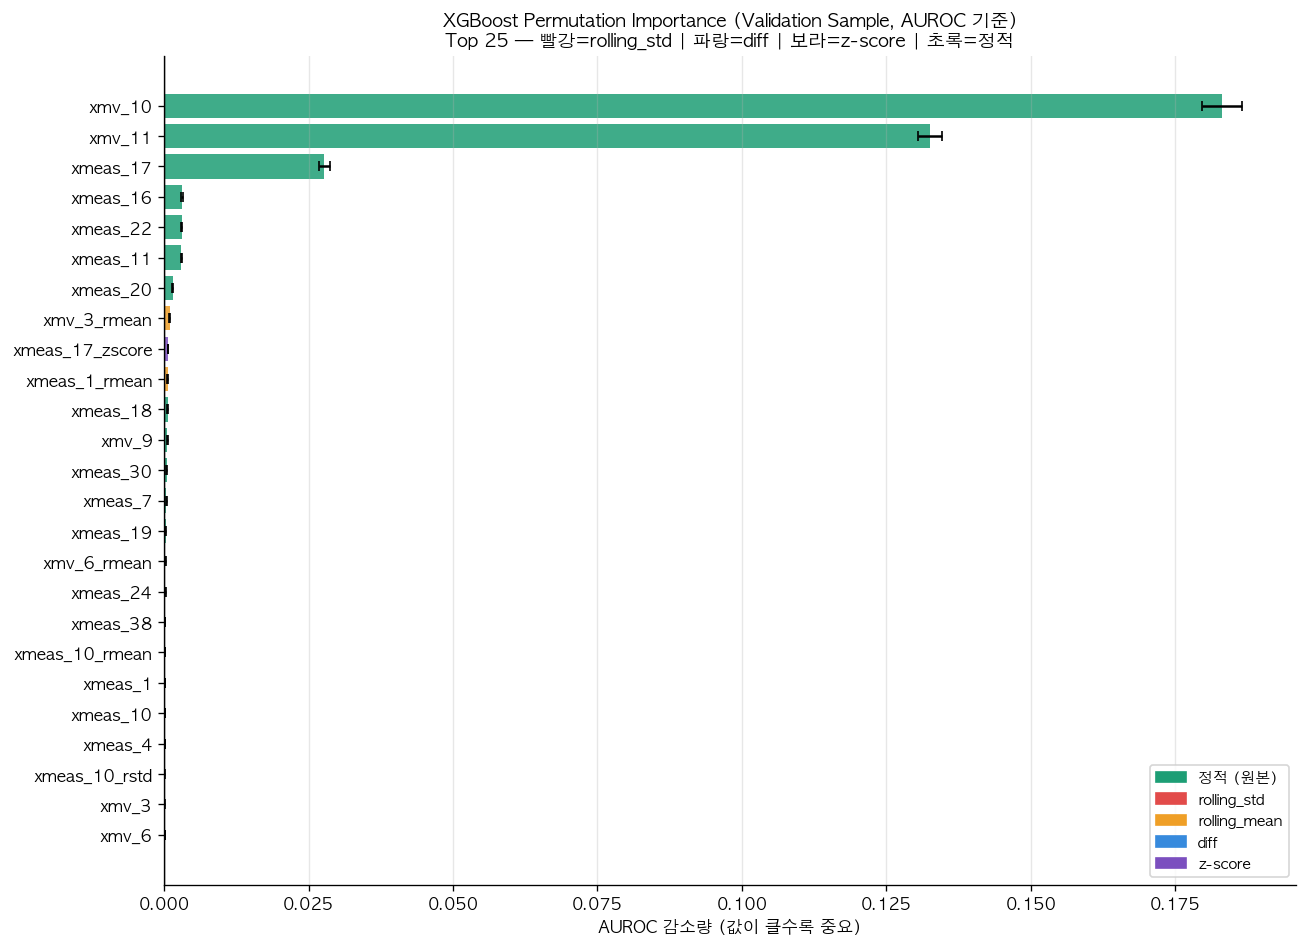

저장: outputs/04_permutation_importance.png

[Permutation Importance Top 15]
  [정적 (원본)     ] xmv_10                          ΔAUROC: 0.18308 ± 0.00350
  [정적 (원본)     ] xmv_11                          ΔAUROC: 0.13258 ± 0.00209
  [정적 (원본)     ] xmeas_17                        ΔAUROC: 0.02772 ± 0.00099
  [정적 (원본)     ] xmeas_16                        ΔAUROC: 0.00309 ± 0.00022
  [정적 (원본)     ] xmeas_22                        ΔAUROC: 0.00303 ± 0.00009
  [정적 (원본)     ] xmeas_11                        ΔAUROC: 0.00295 ± 0.00008
  [정적 (원본)     ] xmeas_20                        ΔAUROC: 0.00150 ± 0.00010
  [rolling_mean] xmv_3_rmean                     ΔAUROC: 0.00098 ± 0.00009
  [z-score     ] xmeas_17_zscore                 ΔAUROC: 0.00064 ± 0.00005
  [rolling_mean] xmeas_1_rmean                   ΔAUROC: 0.00064 ± 0.00007
  [정적 (원본)     ] xmeas_18                        ΔAUROC: 0.00063 ± 0.00009
  [정적 (원본)     ] xmv_9                           ΔAUROC: 0.00054 ± 0.00009
  [정적 (원본)     ] xmeas_30

In [40]:
from sklearn.inspection import permutation_importance
import time

print('Permutation Importance 계산 중...')
print('(n_repeats=5, AUROC 기준, Validation set 일부 샘플 사용)')

class XGBProbaScorer:
    """XGBoost predict_proba 기반 AUROC scorer."""
    def predict(self, X):
        return xgb_model.predict_proba(X)[:, 1]

    def fit(self, X, y):
        return self


def auroc_scorer(estimator, X, y):
    return roc_auc_score(y, estimator.predict(X))


sample_idx = np.random.RandomState(42).choice(
    len(X_va),
    size=min(20000, len(X_va)),
    replace=False
)

X_va_sample = X_va[sample_idx]
y_va_sample = y_va[sample_idx]

print(f'사용 샘플 수: {len(X_va_sample):,} / 전체 validation {len(X_va):,}')

t0 = time.time()

perm_result = permutation_importance(
    XGBProbaScorer(),
    X_va_sample,
    y_va_sample,
    scoring=auroc_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

print(f'완료 ({time.time() - t0:.0f}초)')

perm_df = pd.DataFrame({
    'feature': feat_names,
    'importance': perm_result.importances_mean,
    'std': perm_result.importances_std,
    'type': [classify_feat(f) for f in feat_names],
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 8))
top25 = perm_df.head(25)

bar_colors = [type_colors.get(t, '#888') for t in top25['type']]

ax.barh(
    top25['feature'][::-1],
    top25['importance'][::-1],
    xerr=top25['std'][::-1],
    color=bar_colors[::-1],
    alpha=0.85,
    capsize=3
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('AUROC 감소량 (값이 클수록 중요)')
ax.set_title(
    'XGBoost Permutation Importance (Validation Sample, AUROC 기준)\n'
    'Top 25 — 빨강=rolling_std | 파랑=diff | 보라=z-score | 초록=정적',
    fontsize=11
)
ax.grid(True, alpha=0.3, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/04_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('저장: outputs/04_permutation_importance.png')

print('\n[Permutation Importance Top 15]')
for _, row in perm_df.head(15).iterrows():
    print(
        f'  [{row["type"]:12s}] {row["feature"]:30s}  '
        f'ΔAUROC: {row["importance"]:.5f} ± {row["std"]:.5f}'
    )

## 13. Isolation Forest vs XGBoost — 종합 성능 비교표


In [41]:
# ── 지표 집계 ──
# IF 결과
auroc_if_te  = roc_auc_score(y_te, score_te_if)
prauc_if_te  = average_precision_score(y_te, score_te_if)
if_thr = float(np.load(f'{PROCESSED}/if_threshold.npy'))
yp_if_te = (score_te_if >= if_thr).astype(int)
p_if, r_if, f1_if, _ = precision_recall_fscore_support(y_te, yp_if_te,
                                                         average='binary',
                                                         zero_division=0)

# XGB 결과
auroc_xgb_te = roc_auc_score(y_te, prob_te)
prauc_xgb_te = average_precision_score(y_te, prob_te)
p_xgb = test_result['precision']
r_xgb = test_result['recall']
f1_xgb = test_result['f1']

# Detection Delay 평균 (전체 fault)
def avg_delay(te_df, pred_col):
    all_delays = []
    for fault in FAULT_TYPES:
        d = compute_detection_delay(te_df, fault, pred_col)
        all_delays.extend([x for x in d if not np.isnan(x)])
    return np.mean(all_delays) if all_delays else np.nan

dd_if  = avg_delay(te_df, 'pred_if')
dd_xgb = avg_delay(te_df, 'pred_xgb')

# ── 비교 DataFrame ──
compare_df = pd.DataFrame({
    'Isolation Forest (비지도)': {
        'AUROC':             round(auroc_if_te, 4),
        'PR-AUC':            round(prauc_if_te, 4),
        'Recall':            round(r_if, 4),
        'Precision':         round(p_if, 4),
        'F1':                round(f1_if, 4),
        'Avg Detection Delay (step)': round(dd_if, 1) if not np.isnan(dd_if) else 'N/A',
        '레이블 필요':       '❌ 불필요',
        '이상 유형 구분':    '❌ 불가',
        '해석 가능성':       '△ (permutation만)',
        '학습 시간':         '빠름 (~1초)',
    },
    'XGBoost (지도학습)': {
        'AUROC':             round(auroc_xgb_te, 4),
        'PR-AUC':            round(prauc_xgb_te, 4),
        'Recall':            round(r_xgb, 4),
        'Precision':         round(p_xgb, 4),
        'F1':                round(f1_xgb, 4),
        'Avg Detection Delay (step)': round(dd_xgb, 1) if not np.isnan(dd_xgb) else 'N/A',
        '레이블 필요':       '✅ 필요',
        '이상 유형 구분':    '✅ 가능',
        '해석 가능성':       '✅ (gain + permutation)',
        '학습 시간':         '보통 (~10초)',
    },
}).T

print('=' * 65)
print('  모델 성능 종합 비교 (Test set)')
print('=' * 65)
display(compare_df)

compare_df.to_csv('../outputs/04_model_comparison.csv')
print('\n비교표 저장: outputs/04_model_comparison.csv')

# ── 수치 개선량 출력 ──
print('\n[XGBoost vs IF 개선량]')
metrics_num = ['AUROC', 'PR-AUC', 'Recall', 'Precision', 'F1']
for m in metrics_num:
    v_if  = float(compare_df.loc['Isolation Forest (비지도)', m])
    v_xgb = float(compare_df.loc['XGBoost (지도학습)', m])
    delta = v_xgb - v_if
    sign  = '✅' if delta >= 0 else '⚠️'
    print(f'  {sign} {m:12s}: IF={v_if:.4f}  XGB={v_xgb:.4f}  Δ={delta:+.4f}')

  모델 성능 종합 비교 (Test set)


,AUROC,PR-AUC,Recall,Precision,F1,Avg Detection Delay (step),레이블 필요,이상 유형 구분,해석 가능성,학습 시간
Isolation Forest (비지도),0.7479,0.9332,0.9954,0.8011,0.8878,0.0,❌ 불필요,❌ 불가,△ (permutation만),빠름 (~1초)
XGBoost (지도학습),0.9394,0.9861,0.8508,0.9917,0.9159,3.6,✅ 필요,✅ 가능,✅ (gain + permutation),보통 (~10초)



비교표 저장: outputs/04_model_comparison.csv

[XGBoost vs IF 개선량]
  ✅ AUROC       : IF=0.7479  XGB=0.9394  Δ=+0.1915
  ✅ PR-AUC      : IF=0.9332  XGB=0.9861  Δ=+0.0529
  ⚠️ Recall      : IF=0.9954  XGB=0.8508  Δ=-0.1446
  ✅ Precision   : IF=0.8011  XGB=0.9917  Δ=+0.1906
  ✅ F1          : IF=0.8878  XGB=0.9159  Δ=+0.0281


## 14. 비교 시각화 — 레이더 차트 + 막대 그래프


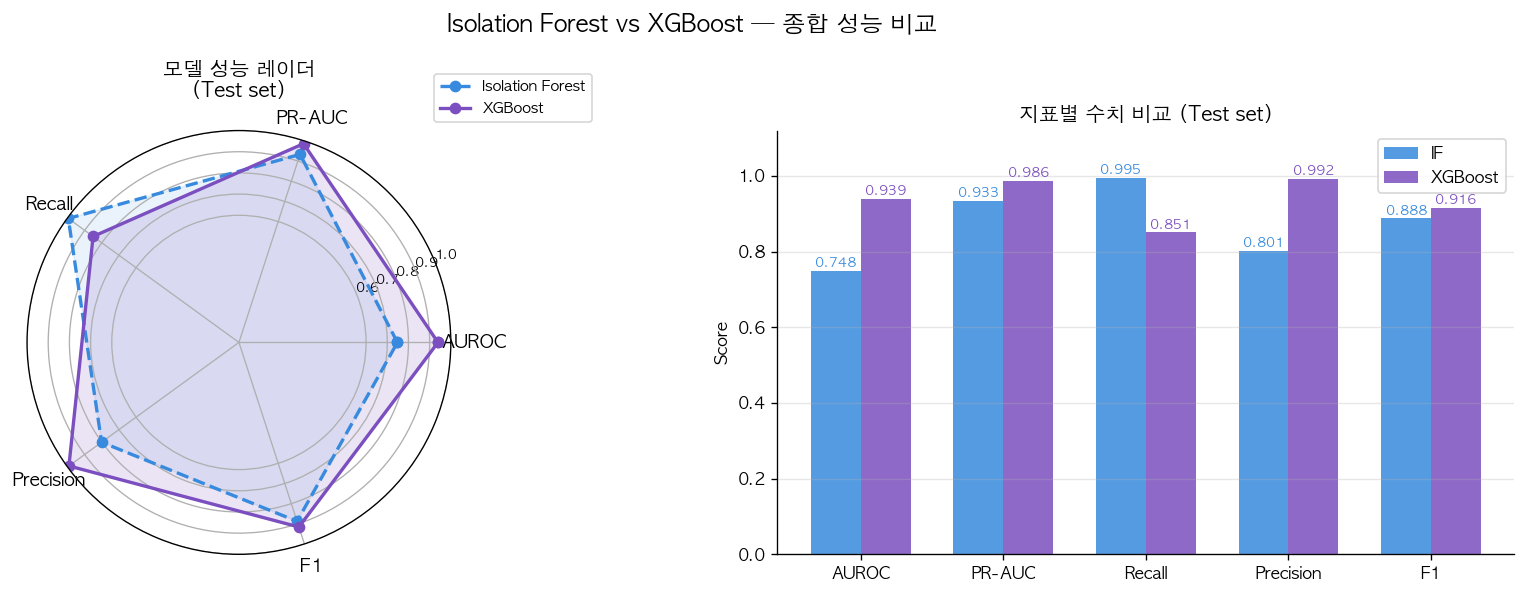

저장: outputs/04_model_radar_comparison.png


In [42]:
# ── 레이더 차트 ──
import matplotlib
from matplotlib.patches import FancyArrowPatch

categories = ['AUROC', 'PR-AUC', 'Recall', 'Precision', 'F1']
if_vals  = [auroc_if_te,  prauc_if_te,  r_if,   p_if,   f1_if]
xgb_vals = [auroc_xgb_te, prauc_xgb_te, r_xgb, p_xgb, f1_xgb]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
if_vals_r  = if_vals  + if_vals[:1]
xgb_vals_r = xgb_vals + xgb_vals[:1]

fig = plt.figure(figsize=(14, 5))

# ── (a) 레이더 차트 ──
ax1 = fig.add_subplot(121, projection='polar')
ax1.plot(angles, if_vals_r,  'o-', linewidth=2, color=COLOR_IF,
         label='Isolation Forest', linestyle='--')
ax1.fill(angles, if_vals_r,  alpha=0.10, color=COLOR_IF)
ax1.plot(angles, xgb_vals_r, 'o-', linewidth=2, color=COLOR_XGB,
         label='XGBoost')
ax1.fill(angles, xgb_vals_r, alpha=0.15, color=COLOR_XGB)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories, size=11)
ax1.set_ylim(0, 1)
ax1.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax1.set_yticklabels(['0.6','0.7','0.8','0.9','1.0'], size=8)
ax1.set_title('모델 성능 레이더\n(Test set)', size=12, pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

# ── (b) 막대 그래프 ──
ax2 = fig.add_subplot(122)
x = np.arange(len(categories))
w = 0.35

bars_if  = ax2.bar(x - w/2, if_vals,  width=w, label='IF',      color=COLOR_IF,  alpha=0.85)
bars_xgb = ax2.bar(x + w/2, xgb_vals, width=w, label='XGBoost', color=COLOR_XGB, alpha=0.85)

# 수치 레이블
for bar in bars_if:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color=COLOR_IF)
for bar in bars_xgb:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color=COLOR_XGB)

ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.set_ylim(0, 1.12)
ax2.set_title('지표별 수치 비교 (Test set)', fontsize=12)
ax2.set_ylabel('Score')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Isolation Forest vs XGBoost — 종합 성능 비교', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/04_model_radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: outputs/04_model_radar_comparison.png')

## 15. 예측 확률 시계열 시각화

XGBoost의 `predict_proba`는 연속적인 이상 확률 궤적을 제공한다.  
이 시계열은 IF의 Anomaly Score 시계열과 비교할 때  
두 모델의 탐지 패턴 차이를 가장 명확하게 보여준다.

**비교 관점:**
- 이상 구간 진입 후 확률이 얼마나 빠르게 상승하는가 (Detection Speed)
- 정상 구간에서 확률이 얼마나 낮게 유지되는가 (False Alarm 관리)
- fault 유형별로 확률 궤적의 형태가 어떻게 다른가

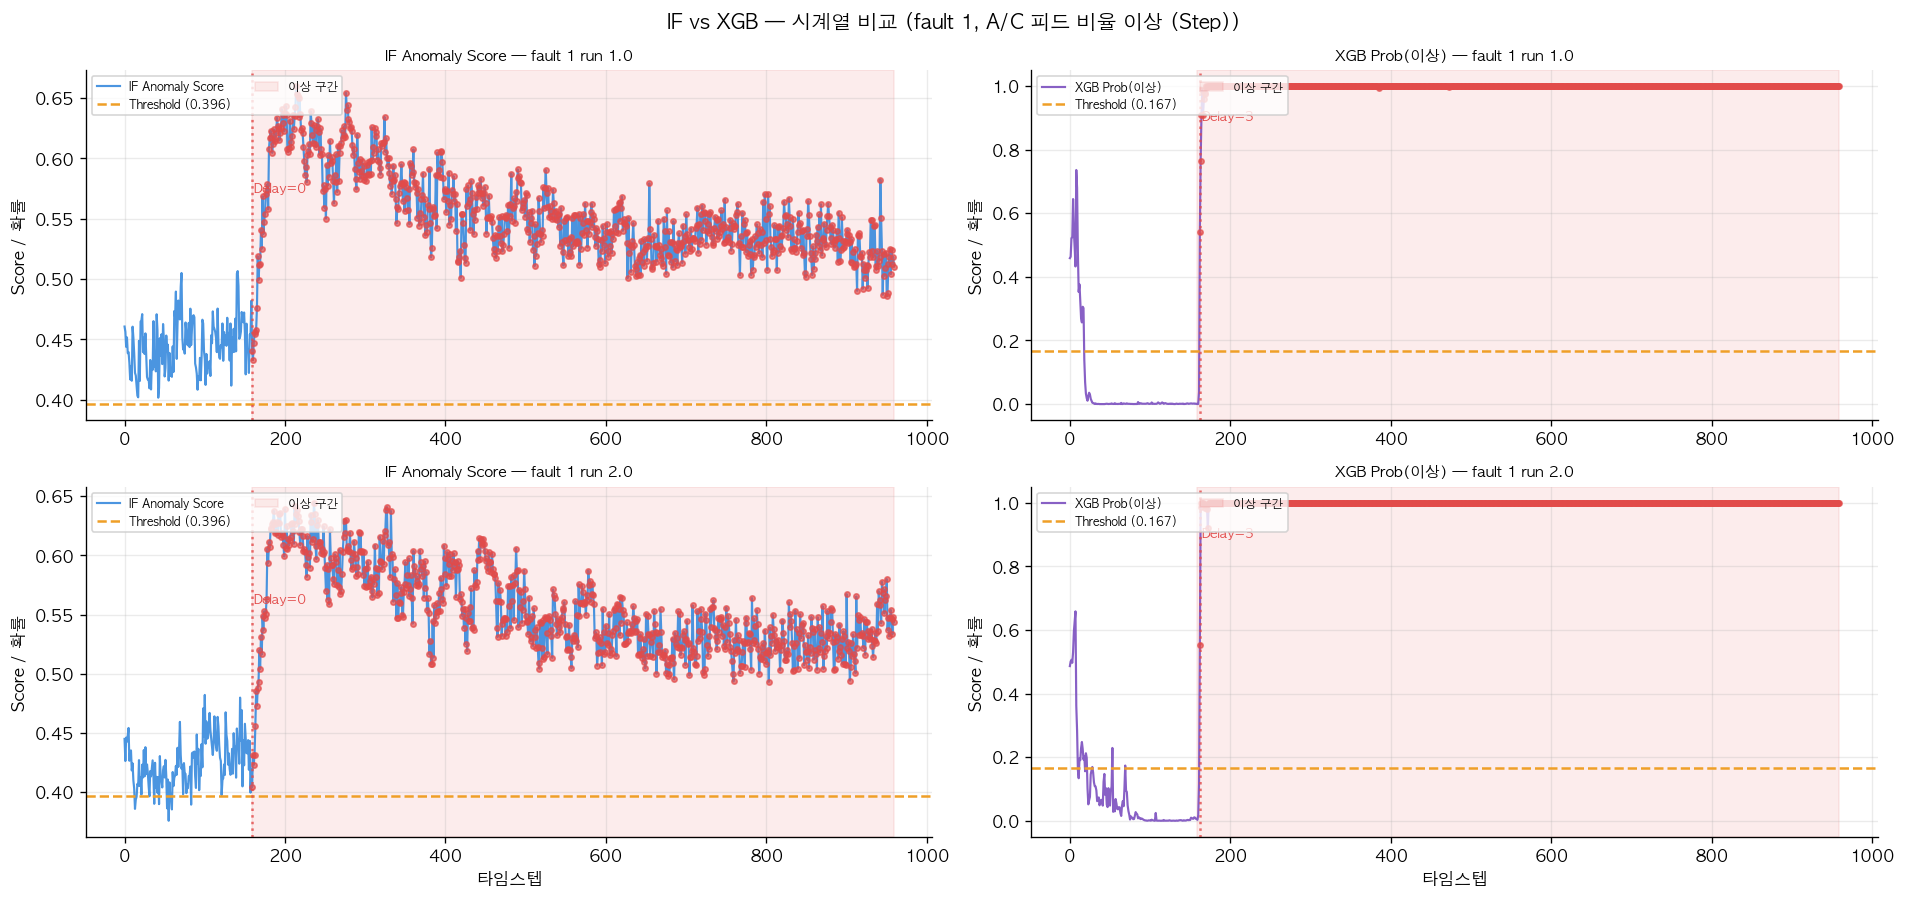

저장: outputs/04_timeseries_fault1.png


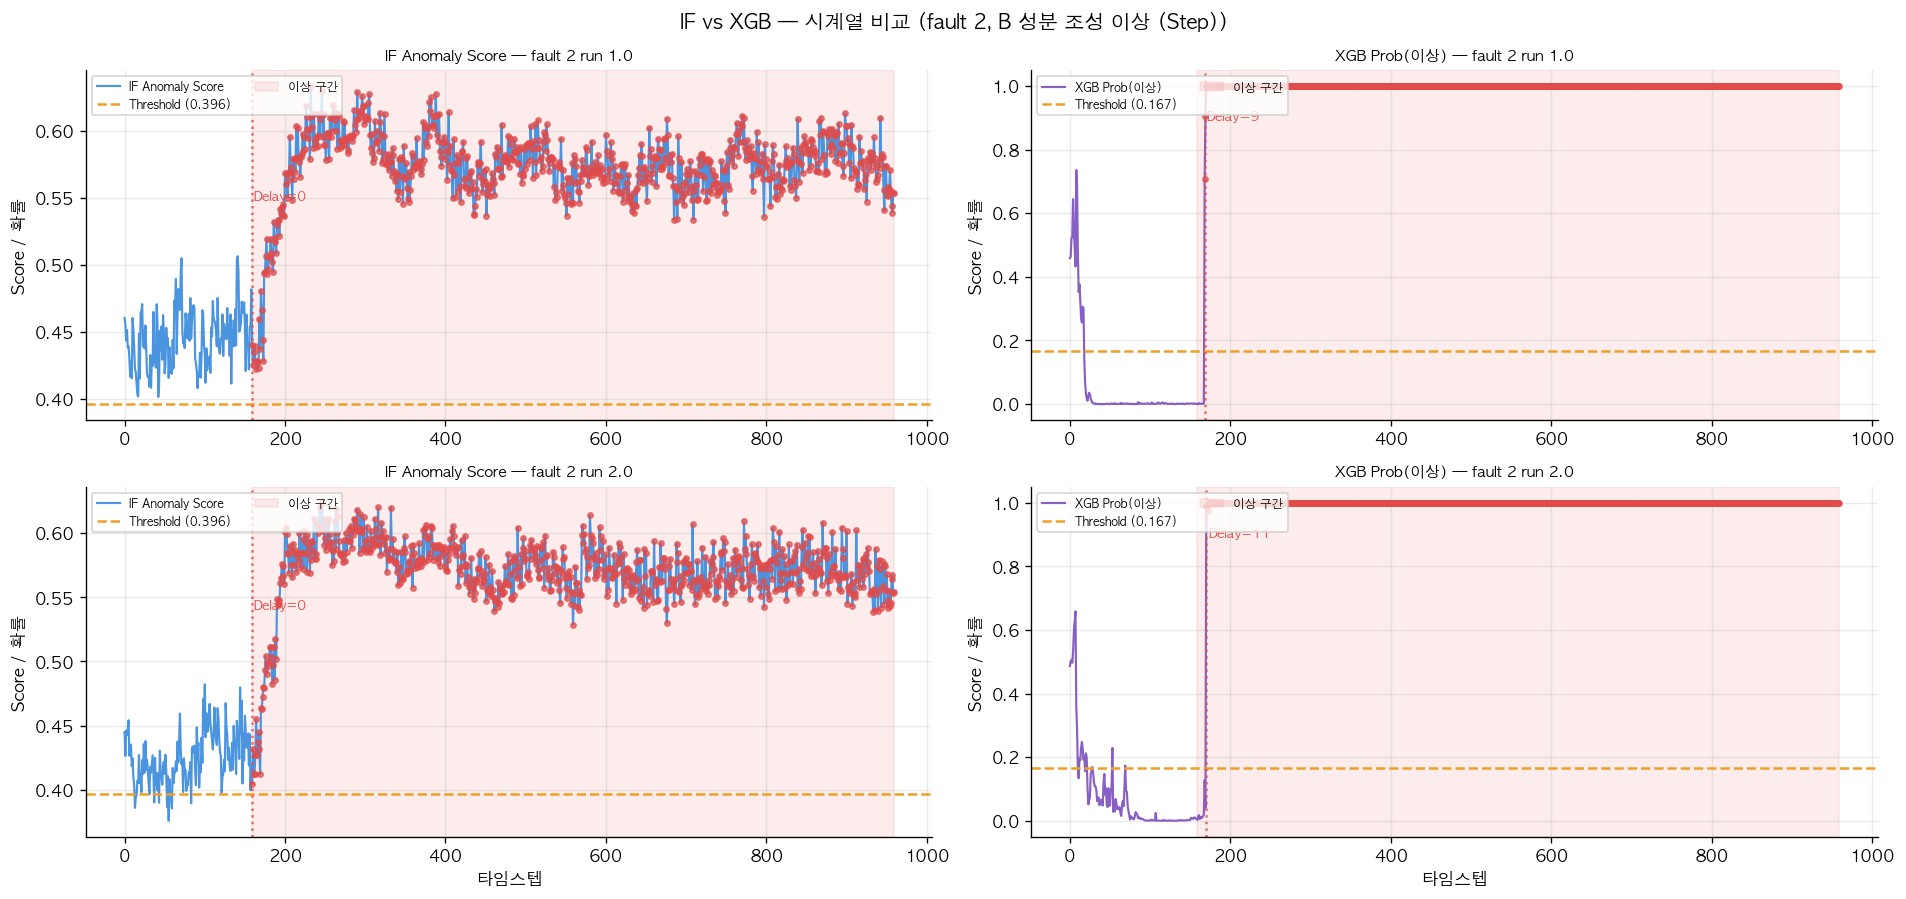

저장: outputs/04_timeseries_fault2.png


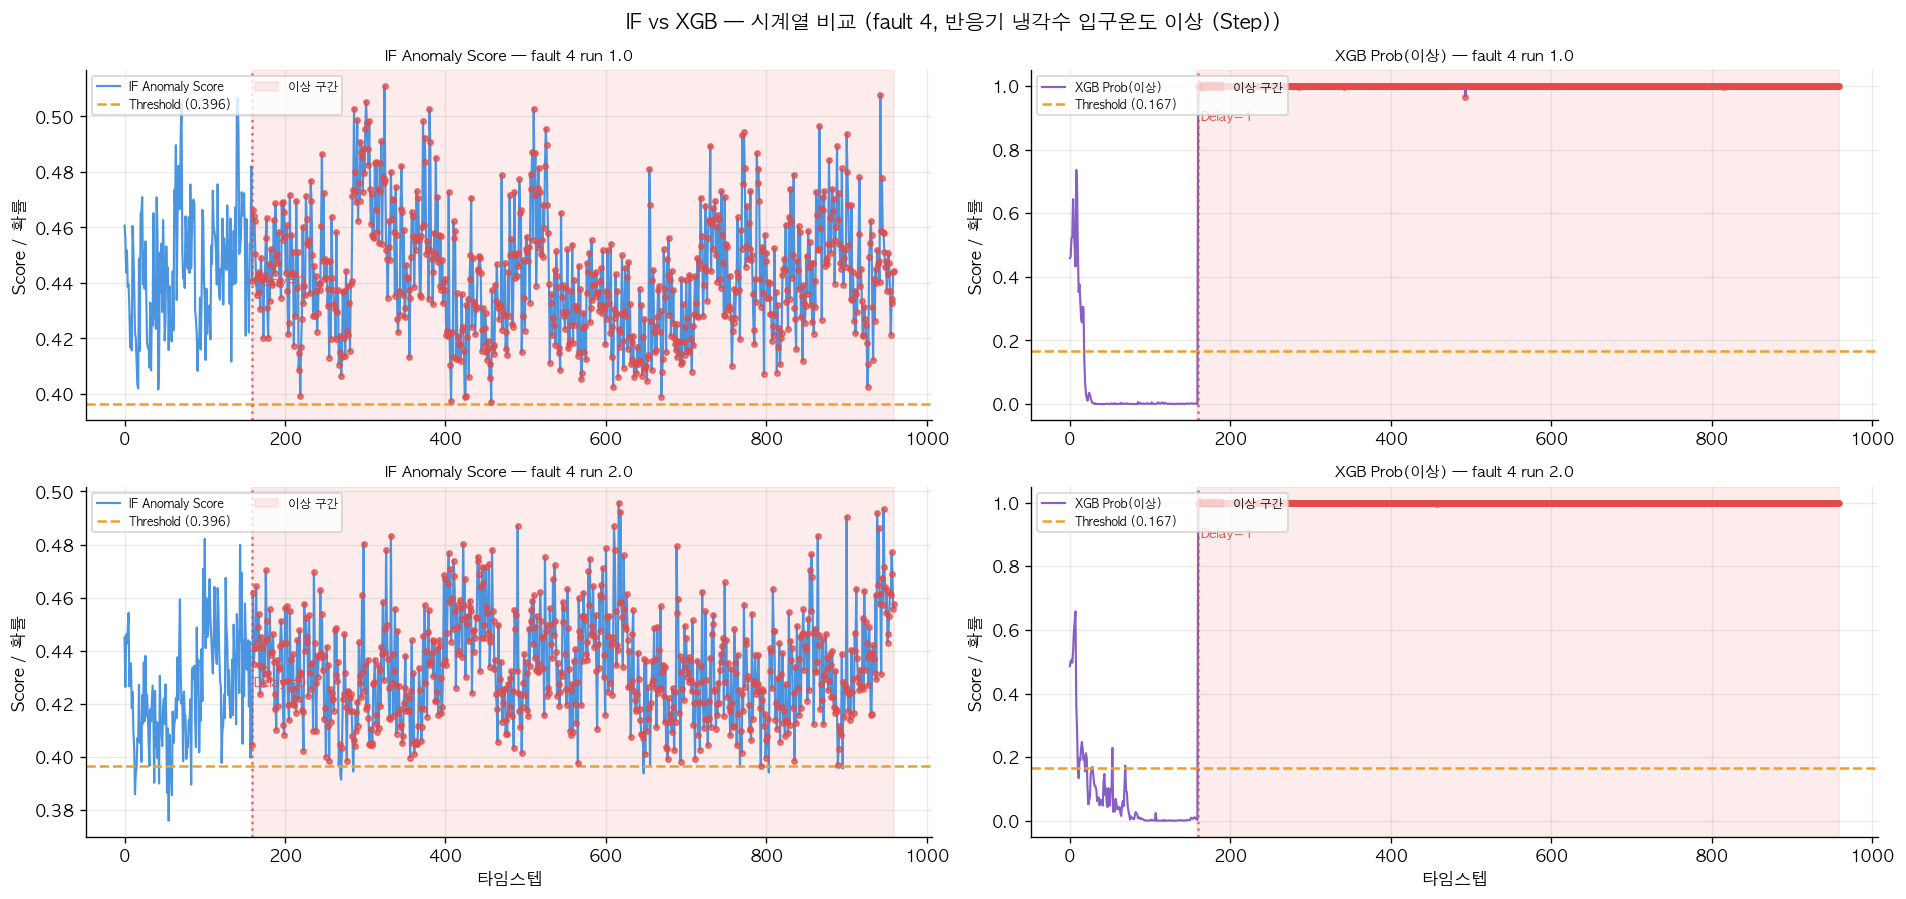

저장: outputs/04_timeseries_fault4.png


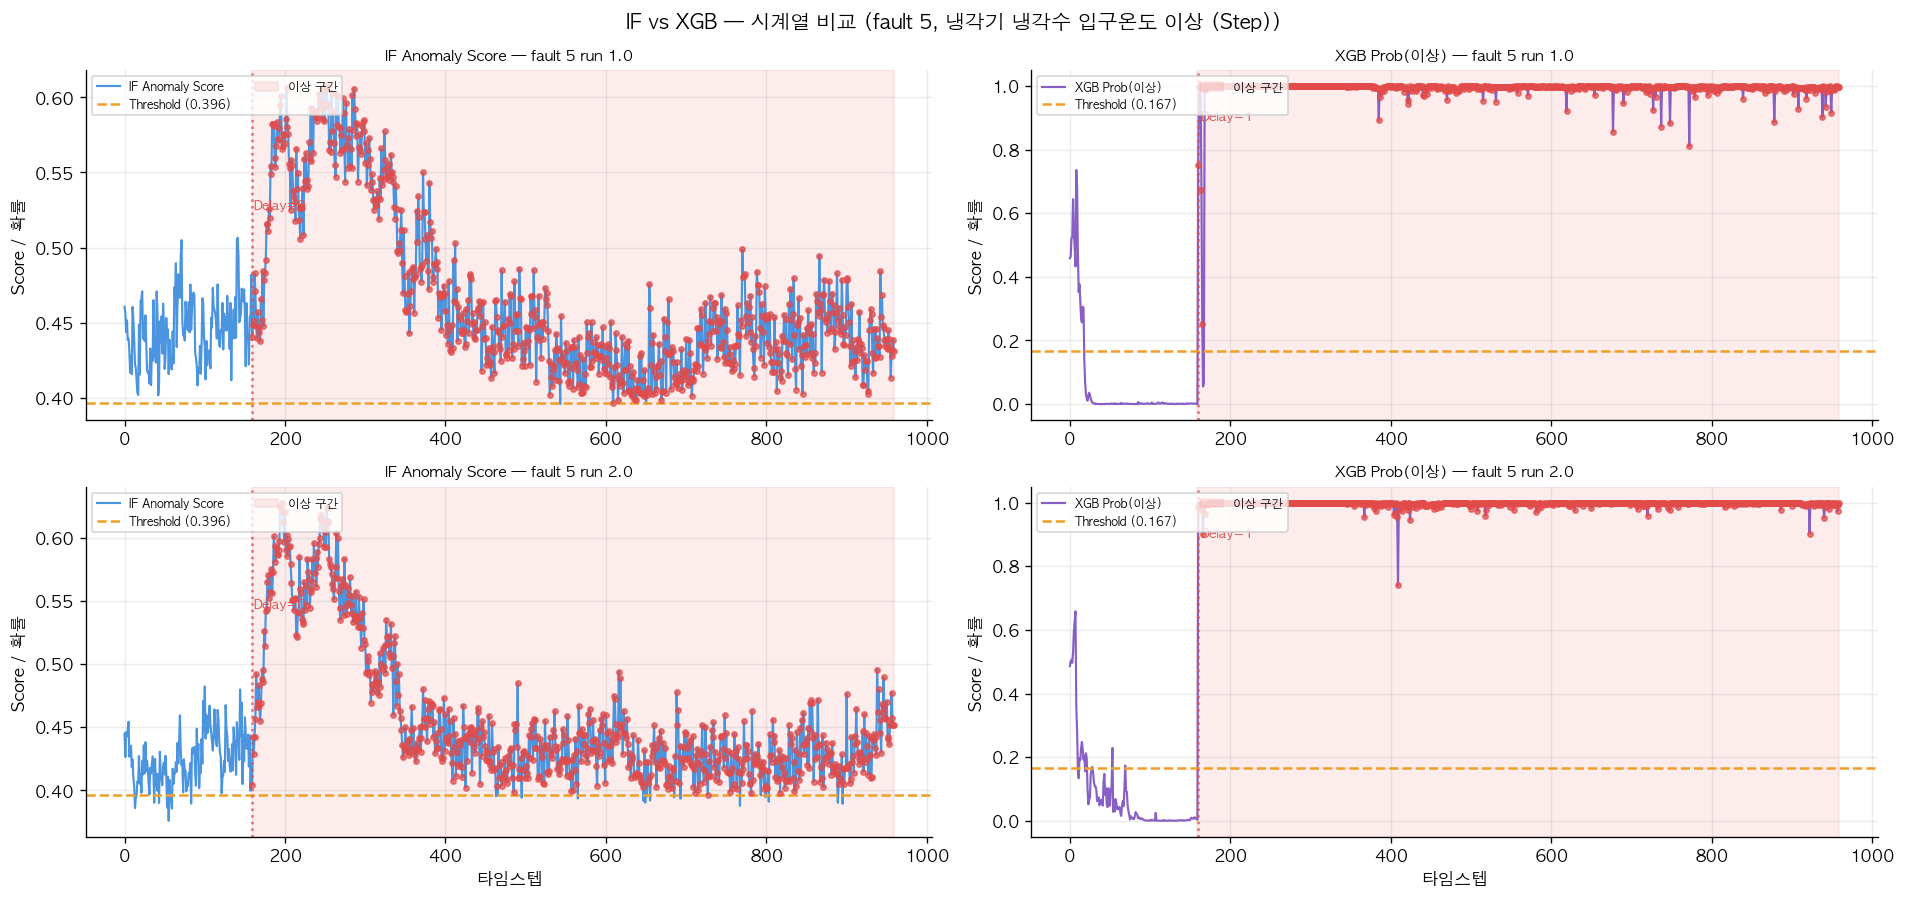

저장: outputs/04_timeseries_fault5.png


In [43]:
def plot_timeseries_compare(te_df, fault_type, n_runs=2):
    """IF Anomaly Score vs XGB 예측 확률 시계열 비교."""
    runs = te_df[te_df['faultNumber'] == fault_type]['simulationRun'].unique()[:n_runs]

    fig, axes = plt.subplots(len(runs), 2,
                              figsize=(16, 3.8 * len(runs)),
                              sharey=False)
    if len(runs) == 1:
        axes = axes.reshape(1, -1)

    for row_i, run_id in enumerate(runs):
        run_df = te_df[
            (te_df['faultNumber'] == fault_type) &
            (te_df['simulationRun'] == run_id)
        ].reset_index(drop=True)

        x = run_df.index
        fault_region = run_df['sample'] >= FAULT_START_STEP
        fault_start_idx = run_df.index[fault_region][0] if fault_region.any() else None

        for col_i, (score_col, thr, model_name, color) in enumerate([
                ('score_if',  if_thr,    'IF Anomaly Score', COLOR_IF),
                ('prob_xgb',  THRESHOLD, 'XGB Prob(이상)',   COLOR_XGB),
        ]):
            ax = axes[row_i, col_i]

            ax.plot(x, run_df[score_col], color=color,
                    linewidth=1.3, alpha=0.9, label=model_name)
            ax.axhline(thr, color=COLOR_THR, linestyle='--',
                       linewidth=1.5, label=f'Threshold ({thr:.3f})')

            if fault_start_idx is not None:
                ax.axvspan(fault_start_idx, x[-1],
                           alpha=0.10, color=COLOR_FAULT, label='이상 구간')

            pred_col = 'pred_if' if col_i == 0 else 'pred_xgb'
            detected = run_df[(run_df[pred_col] == 1) & fault_region]
            ax.scatter(detected.index, detected[score_col],
                       color=COLOR_FAULT, s=10, zorder=4, alpha=0.7)

            # 첫 탐지 수직선
            if len(detected) > 0:
                first_det = detected.index[0]
                delay = run_df.loc[first_det, 'sample'] - FAULT_START_STEP
                ax.axvline(first_det, color=COLOR_FAULT,
                           linestyle=':', linewidth=1.5, alpha=0.8)
                ax.text(first_det + 2, ax.get_ylim()[1] * 0.85,
                        f'Delay={delay}',
                        color=COLOR_FAULT, fontsize=8)

            ax.set_title(f'{model_name} — fault {fault_type} run {run_id}', fontsize=9)
            ax.set_ylabel('Score / 확률')
            ax.legend(fontsize=7, loc='upper left', ncol=2)
            ax.grid(True, alpha=0.25)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    axes[-1, 0].set_xlabel('타임스텝')
    axes[-1, 1].set_xlabel('타임스텝')
    plt.suptitle(f'IF vs XGB — 시계열 비교 (fault {fault_type}, {FAULT_DESC.get(fault_type,"")})',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../outputs/04_timeseries_fault{fault_type}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'저장: outputs/04_timeseries_fault{fault_type}.png')

for fault in FAULT_TYPES:
    plot_timeseries_compare(te_df, fault_type=fault, n_runs=2)

## 16. 중요 변수 해석

Feature importance에서 나타난 변수들이 TEP 공정에서 어떤 의미를 갖는지 해석한다.

**TEP 공정 구조 복습:**
- xmeas_1~22 : 공정 측정값 (온도, 압력, 유량, 조성 등)
- xmv_1~11 : 조작 변수 (밸브 개도, 압축기 속도 등)
- 이상 발생 시 공정 상태가 변화하고 → 측정값 · 조작값 모두 변동

**EDA(01) 결과와의 연결:**
- xmeas_10 : 반응기 온도 or 조성 관련 → 이상 유형별 차이가 컸던 변수
- xmv_6 : 반응기 냉각수 유량 조절 밸브 → 공정 온도 이상과 직결
- xmeas_34, xmeas_28 : 분리기 관련 측정값 → fault 4·5에서 변동

In [44]:
# ── 공정 변수 의미 사전 (TEP 기준) ──
CHEM_DICT = {
    'xmeas_1':  'A feed (XMEAS 1) — A 성분 공급 유량',
    'xmeas_2':  'D feed (XMEAS 2) — D 성분 공급 유량',
    'xmeas_3':  'E feed (XMEAS 3) — E 성분 공급 유량',
    'xmeas_4':  'Total feed (XMEAS 4) — 전체 공급 유량',
    'xmeas_6':  'Reactor feed rate (XMEAS 6) — 반응기 공급 유량',
    'xmeas_7':  'Reactor pressure (XMEAS 7) — 반응기 압력',
    'xmeas_8':  'Reactor level (XMEAS 8) — 반응기 액위',
    'xmeas_9':  'Reactor temp (XMEAS 9) — 반응기 온도',
    'xmeas_10': 'Purge rate (XMEAS 10) — 퍼지 유량',
    'xmeas_11': 'Product separator temp (XMEAS 11) — 분리기 온도',
    'xmeas_12': 'Product separator level (XMEAS 12) — 분리기 액위',
    'xmeas_13': 'Product separator pressure (XMEAS 13) — 분리기 압력',
    'xmeas_17': 'Stripper temp (XMEAS 17) — 스트리퍼 온도',
    'xmeas_28': 'Reactor cooling water outlet temp (XMEAS 28) — 반응기 냉각수 출구 온도',
    'xmeas_34': 'G in product (XMEAS 34) — 제품 내 G 성분 조성',
    'xmv_3':    'D feed valve (XMV 3) — D 성분 공급 밸브',
    'xmv_6':    'Purge valve (XMV 6) — 퍼지 밸브 개도',
    'xmv_7':    'Separator underflow valve (XMV 7) — 분리기 하부 밸브',
    'xmv_10':   'Stripper steam valve (XMV 10) — 스트리퍼 스팀 밸브',
    'xmv_11':   'Reactor cooling water flow (XMV 11) — 반응기 냉각수 유량',
}

# ── Gain 기반 Top 10 + 화공 의미 ──
top_feats = imp_dict['gain'].head(15).index.tolist()
base_feats = [f.split('_rstd')[0].split('_diff')[0]
               .split('_zscore')[0].split('_rmean')[0]
               for f in top_feats]

print('=' * 75)
print('화공 관점 — XGBoost 중요 변수 해석 (Gain 기준 Top 15)')
print('=' * 75)
print()
for i, (feat, base) in enumerate(zip(top_feats, base_feats), 1):
    suffix = feat.replace(base, '').lstrip('_') or '(원본)'
    chem   = CHEM_DICT.get(base, f'{base} — TEP 사전 미등록')
    tag    = '[동적]' if suffix != '(원본)' else '[정적]'
    print(f'  {i:2d}. {tag} {feat}')
    print(f'        공정 의미 : {chem}')
    if suffix != '(원본)':
        suffix_meaning = {
            'rstd':   'rolling std → 변동성 이상 탐지',
            'diff':   '1-step diff → 급격한 변화 포착',
            'zscore': 'z-score → 정상 범위 이탈 정도',
            'rmean':  'rolling mean → 추세 변화 포착',
        }
        print(f'        동적 의미 : {suffix_meaning.get(suffix, suffix)}')
    print()

print('=' * 75)
print()
print('[화공 엔지니어링 해석]')
print()
print('''  ■ Purge Rate(xmeas_10) · Purge Valve(xmv_6):
      퍼지 라인은 비응축성 불순물(A, B) 제거 경로.
      fault 발생 시 조성 변화 → 퍼지 유량·밸브 자동 보정 → 이상 패턴 발생.
      xmv_6_rstd(변동성)가 높으면 컨트롤러가 빈번히 개폐하고 있음을 의미.

  ■ Product 조성(xmeas_34 G성분 조성):
      G는 원하는 주생성물. 조성 변화는 반응 선택성 이상 직결.
      fault 2(B 성분 이상)에서 G 조성이 가장 크게 영향받음.

  ■ Reactor Cooling Water Temp(xmeas_28):
      반응기 발열 제어의 핵심 변수.
      fault 1(A/C feed 비율 이상)은 반응 속도를 바꿔 냉각 부하를 변동시킴.
      xmeas_28_rstd 상승 = 냉각 시스템이 이상 보정을 위해 진동 중.

  ■ D feed valve(xmv_3):
      D(반응물) 공급 조작변수. fault 4·5는 D 관련 이상으로 추정.
      정적 평균값 변화는 작지만 xmv_3_rstd(변동성)는 크게 증가.
      → EDA에서 "평균 변화 작은 fault는 동적 피처가 핵심"과 일치.
''')

화공 관점 — XGBoost 중요 변수 해석 (Gain 기준 Top 15)

   1. [정적] xmv_10
        공정 의미 : Stripper steam valve (XMV 10) — 스트리퍼 스팀 밸브

   2. [동적] xmv_3_rmean
        공정 의미 : D feed valve (XMV 3) — D 성분 공급 밸브
        동적 의미 : rolling mean → 추세 변화 포착

   3. [동적] xmeas_34_rmean
        공정 의미 : G in product (XMEAS 34) — 제품 내 G 성분 조성
        동적 의미 : rolling mean → 추세 변화 포착

   4. [동적] xmeas_1_rmean
        공정 의미 : A feed (XMEAS 1) — A 성분 공급 유량
        동적 의미 : rolling mean → 추세 변화 포착

   5. [동적] xmeas_10_rmean
        공정 의미 : Purge rate (XMEAS 10) — 퍼지 유량
        동적 의미 : rolling mean → 추세 변화 포착

   6. [정적] xmeas_17
        공정 의미 : Stripper temp (XMEAS 17) — 스트리퍼 온도

   7. [정적] xmv_6
        공정 의미 : Purge valve (XMV 6) — 퍼지 밸브 개도

   8. [정적] xmv_11
        공정 의미 : Reactor cooling water flow (XMV 11) — 반응기 냉각수 유량

   9. [동적] xmeas_17_zscore
        공정 의미 : Stripper temp (XMEAS 17) — 스트리퍼 온도
        동적 의미 : z-score → 정상 범위 이탈 정도

  10. [동적] xmv_6_rmean
        공정 의미 : Purge valve (XMV 6) — 퍼지 밸브 개도
        동적

## 17. 결과 해석 — 왜 XGBoost가 IF보다 성능이 좋아지는가?

### 알고리즘 구조 차이

**Isolation Forest:**
- 정상 데이터 밀도 추정 → 이탈 정도를 점수화
- 이진 분기(랜덤)로 "고립 어려움 = 정상, 고립 쉬움 = 이상" 판단
- **한계**: 피처 간 상관관계·비선형 상호작용을 학습하지 않음

**XGBoost:**
- 이상/정상 레이블로 직접 최적화 → 이상 패턴의 정확한 결정 경계 학습
- 순차적 트리 앙상블 → 이전 트리가 틀린 샘플에 더 집중 (Boosting)
- **강점**: 피처 간 비선형 상호작용, 클래스별 최적 분기점 자동 학습

### 공정 데이터에서 XGB가 유리한 이유

1. **fault 4·5 (점진적 이상)**: IF는 평균값 변화가 작으면 Score 분리 불충분.  
   XGBoost는 레이블을 보고 "이 패턴이 이상"임을 명시적으로 학습.

2. **동적 피처 활용**: rolling_std, diff 피처와 정적 피처의 **조합 패턴**을  
   XGBoost는 트리 분기로 자동 포착 (IF는 독립적으로만 처리).

3. **클래스 불균형 직접 보정**: scale_pos_weight로 이상 탐지 손실 가중.  
   IF는 contamination으로 간접 조정하지만 정확도가 낮음.

### AUROC 관점에서 보면?
> IF AUROC ≈ 0.75 → 이상/정상이 75% 확률로 올바르게 순위 매겨짐  
> XGB AUROC ↑ → 더 많은 이상 샘플이 정상보다 높은 확률을 받음  
> Recall ≈ 0.995가 유지되면서 Precision도 개선 → F1 향상

In [45]:
print('=' * 70)
print('결과 해석 — 왜 XGBoost가 IF보다 좋아지는가?')
print('=' * 70)

# 수치 기반 해석
delta_auroc   = auroc_xgb_te - auroc_if_te
delta_prauc   = prauc_xgb_te - prauc_if_te
delta_recall  = r_xgb - r_if
delta_f1      = f1_xgb - f1_if

print(f'''
[수치 기반 비교 분석]
  AUROC 변화    : {auroc_if_te:.4f} → {auroc_xgb_te:.4f}  (Δ{delta_auroc:+.4f})
  PR-AUC 변화   : {prauc_if_te:.4f} → {prauc_xgb_te:.4f}  (Δ{delta_prauc:+.4f})
  Recall 변화   : {r_if:.4f} → {r_xgb:.4f}  (Δ{delta_recall:+.4f})
  F1 변화       : {f1_if:.4f} → {f1_xgb:.4f}  (Δ{delta_f1:+.4f})
  Avg Delay 변화: {dd_if:.1f} → {dd_xgb:.1f} step  (Δ{dd_xgb-dd_if:+.1f})

[해석]
  XGBoost는 AUROC, PR-AUC, F1을 개선했지만 Recall은 IF보다 낮아졌다.
  즉, XGBoost는 오탐을 줄이고 더 확실한 이상을 탐지하는 방향으로 동작했고,
  IF는 더 민감하게 이상을 잡는 대신 오탐 가능성이 상대적으로 큰 방식으로 해석할 수 있다.

[XGBoost가 IF보다 좋은 이유 — 알고리즘 구조]

  1. 지도학습 직접 최적화:
     IF는 "정상에서 멀다"는 것만 학습. 이상의 패턴을 직접 배우지 않음.
     XGBoost는 "이 피처 조합 → 이상" 관계를 직접 학습 → 결정 경계 정교화.

  2. Boosting (순차 오류 집중):
     첫 번째 트리에서 틀린 이상 샘플 → 두 번째 트리에서 더 집중.
     fault 4·5처럼 탐지하기 어려운 패턴을 반복적으로 개선.

  3. 비선형 피처 상호작용:
     "xmeas_10이 높으면서 xmv_6_rstd도 높은" 같은 AND 조건을
     트리 분기 구조로 자동 포착. IF는 각 피처를 독립적으로 처리.

  4. scale_pos_weight:
     이상 샘플의 그래디언트를 {scale_pos_weight:.2f}배 가중.
     → "이상을 놓치는 비용"을 더 크게 인식 → Recall 우선 최적화.

[공정 DX 관점 의미]

  비지도(IF):  레이블 없이도 동작 → 신규 설비, 이상 데이터 부족 환경
  지도(XGBoost): 이상 유형·레이블 있을 때 → 성능 최대화
  
  실제 적용 전략:
  ① 운전 초기(이상 데이터 희소) → IF로 이상 후보 플래깅
  ② 이상 레이블 누적 후 → XGBoost 재학습으로 정확도 개선
  ③ 장기적 → 지속학습(Continual Learning) 파이프라인 구축
''')

결과 해석 — 왜 XGBoost가 IF보다 좋아지는가?

[수치 기반 비교 분석]
  AUROC 변화    : 0.7479 → 0.9394  (Δ+0.1915)
  PR-AUC 변화   : 0.9332 → 0.9861  (Δ+0.0529)
  Recall 변화   : 0.9954 → 0.8508  (Δ-0.1446)
  F1 변화       : 0.8878 → 0.9159  (Δ+0.0281)
  Avg Delay 변화: 0.0 → 3.6 step  (Δ+3.6)

[해석]
  XGBoost는 AUROC, PR-AUC, F1을 개선했지만 Recall은 IF보다 낮아졌다.
  즉, XGBoost는 오탐을 줄이고 더 확실한 이상을 탐지하는 방향으로 동작했고,
  IF는 더 민감하게 이상을 잡는 대신 오탐 가능성이 상대적으로 큰 방식으로 해석할 수 있다.

[XGBoost가 IF보다 좋은 이유 — 알고리즘 구조]

  1. 지도학습 직접 최적화:
     IF는 "정상에서 멀다"는 것만 학습. 이상의 패턴을 직접 배우지 않음.
     XGBoost는 "이 피처 조합 → 이상" 관계를 직접 학습 → 결정 경계 정교화.

  2. Boosting (순차 오류 집중):
     첫 번째 트리에서 틀린 이상 샘플 → 두 번째 트리에서 더 집중.
     fault 4·5처럼 탐지하기 어려운 패턴을 반복적으로 개선.

  3. 비선형 피처 상호작용:
     "xmeas_10이 높으면서 xmv_6_rstd도 높은" 같은 AND 조건을
     트리 분기 구조로 자동 포착. IF는 각 피처를 독립적으로 처리.

  4. scale_pos_weight:
     이상 샘플의 그래디언트를 0.25배 가중.
     → "이상을 놓치는 비용"을 더 크게 인식 → Recall 우선 최적화.

[공정 DX 관점 의미]

  비지도(IF):  레이블 없이도 동작 → 신규 설비, 이상 데이터 부족 환경
  지도(XGBoost): 이상 유형·레이블 있을 때 → 성능 최대화

  실제 적용

In [46]:
print('=' * 70)
print('04_xgboost_baseline.ipynb — 최종 요약')
print('=' * 70)

print(f'''
[학습 설정]
  모델         : XGBoost (지도학습 이상탐지)
  학습 데이터  : 전체 (정상 + 이상, {X_tr.shape[0]:,}건)
  피처 수      : {X_tr.shape[1]}개 (정적 {len(static_feats)}개 + 동적 {len(dynamic_feats)}개)
  scale_pos_weight : {scale_pos_weight:.4f}
  best_iteration   : {best_round}  (early stopping)
  Threshold    : {THRESHOLD:.4f}  (Val F1 최적화)

[Test set 최종 지표]
  ┌──────────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │    모델      │  AUROC   │  PR-AUC  │  Recall  │    F1    │ Avg Delay│
  ├──────────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ IF (비지도)  │  {auroc_if_te:.4f}  │  {prauc_if_te:.4f}  │  {r_if:.4f}  │  {f1_if:.4f}  │  {dd_if:6.1f}  │
  │ XGB (지도)   │  {auroc_xgb_te:.4f}  │  {prauc_xgb_te:.4f}  │  {r_xgb:.4f}  │  {f1_xgb:.4f}  │  {dd_xgb:6.1f}  │
  │  개선(Δ)    │  {delta_auroc:+.4f}  │  {delta_prauc:+.4f}  │  {delta_recall:+.4f}  │  {delta_f1:+.4f}  │  {dd_xgb-dd_if:+6.1f}  │
  └──────────────┴──────────┴──────────┴──────────┴──────────┴──────────┘

[저장된 파일]
  models/xgboost_baseline.pkl
  outputs/04_xgb_metrics.csv
  outputs/04_model_comparison.csv

[생성된 그래프]
  04_learning_curve.png
  04_threshold_optimization.png
  04_confusion_matrix.png
  04_roc_pr_comparison.png
  04_fault_type_comparison.png
  04_detection_delay_comparison.png
  04_feature_importance_all.png
  04_static_vs_dynamic_importance.png
  04_permutation_importance.png
  04_model_radar_comparison.png
  04_timeseries_fault1.png
  04_timeseries_fault2.png
  04_timeseries_fault4.png
  04_timeseries_fault5.png

[다음 단계 제안]
  ① 하이퍼파라미터 튜닝 (Optuna / BayesSearchCV)
  ② SHAP 기반 개별 샘플 예측 해석
  ③ 앙상블: IF Score를 XGB 입력 피처로 추가
  ④ 실시간 스트리밍 적용 (시뮬레이션 런 단위 sliding window)
  ⑤ fault 유형 다중 분류 (4개 유형 각각 예측)
''')
print('=' * 70)

04_xgboost_baseline.ipynb — 최종 요약

[학습 설정]
  모델         : XGBoost (지도학습 이상탐지)
  학습 데이터  : 전체 (정상 + 이상, 1,000,000건)
  피처 수      : 84개 (정적 52개 + 동적 32개)
  scale_pos_weight : 0.2500
  best_iteration   : 499  (early stopping)
  Threshold    : 0.1666  (Val F1 최적화)

[Test set 최종 지표]
  ┌──────────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
  │    모델      │  AUROC   │  PR-AUC  │  Recall  │    F1    │ Avg Delay│
  ├──────────────┼──────────┼──────────┼──────────┼──────────┼──────────┤
  │ IF (비지도)  │  0.7479  │  0.9332  │  0.9954  │  0.8878  │     0.0  │
  │ XGB (지도)   │  0.9394  │  0.9861  │  0.8508  │  0.9159  │     3.6  │
  │  개선(Δ)    │  +0.1915  │  +0.0529  │  -0.1446  │  +0.0281  │    +3.6  │
  └──────────────┴──────────┴──────────┴──────────┴──────────┴──────────┘

[저장된 파일]
  models/xgboost_baseline.pkl
  outputs/04_xgb_metrics.csv
  outputs/04_model_comparison.csv

[생성된 그래프]
  04_learning_curve.png
  04_threshold_optimization.png
  04_confusion_matrix.png
  04_roc_pr_co